# 03 — Exploratory Data Analysis & Visualization
**FlightIQ — AI Travel Price Intelligence**

MIC AIML Department Recruitment Challenge  
Track: Data Science & Visualization — AI Travel Analyst

---
**Dataset**: `data/processed/cleaned_flight_data.csv` — 93,083 rows × 27 columns  
**Target**: `Price` (INR)  
**Goal**: Identify strong price-related patterns through univariate, bivariate, and multivariate analysis.

> All charts are saved to `assets/eda/`. All insights are backed by numerical evidence from the dataset.

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

sys.path.insert(0, os.path.abspath('../src'))
from visualization import (
    plot_price_distribution, plot_airline_vs_price, plot_travel_class_vs_price,
    plot_stops_vs_price, plot_source_dest_vs_price, plot_duration_vs_price,
    plot_time_vs_price, plot_routes_vs_price, plot_correlation_heatmap,
    plot_price_by_calendar, plot_season_channel_vs_price, plot_days_before_departure,
    run_all_eda, EDA_DIR
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('../data/processed/cleaned_flight_data.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Target: Price | range ₹{df["Price"].min():,.0f} – ₹{df["Price"].max():,.0f}')

Loaded: 93,083 rows × 27 columns
Target: Price | range ₹152 – ₹999,306


## Dataset Quick Overview

In [2]:
print('=== Columns & dtypes ===')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2}. {c:<35s} dtype={str(df[c].dtype):<10} nunique={df[c].nunique()}')

=== Columns & dtypes ===
   1. Flight_ID                           dtype=object     nunique=93083
   2. Airline                             dtype=object     nunique=13
   3. Source                              dtype=object     nunique=18
   4. Destination                         dtype=object     nunique=18
   5. Departure_Date                      dtype=object     nunique=730
   6. Departure_Time                      dtype=object     nunique=576
   7. Arrival_Time                        dtype=object     nunique=2880
   8. Duration                            dtype=object     nunique=5082
   9. Total_Stops                         dtype=object     nunique=6
  10. Distance_km                         dtype=float64    nunique=54861
  11. Travel_Class                        dtype=object     nunique=4
  12. Days_Before_Departure               dtype=float64    nunique=181
  13. Season                              dtype=object     nunique=4
  14. Weekday                             dtype=object 

In [3]:
print('Price summary statistics:')
print(df['Price'].describe().apply(lambda x: f'₹{x:>12,.2f}'))

Price summary statistics:
count    ₹   93,083.00
mean     ₹   72,990.28
std      ₹   77,721.80
min      ₹      152.13
25%      ₹   13,258.57
50%      ₹   49,100.13
75%      ₹  113,660.48
max      ₹  999,306.03
Name: Price, dtype: object


---
## 1 · Price Distribution (Univariate)

  Saved → 01_price_distribution.png


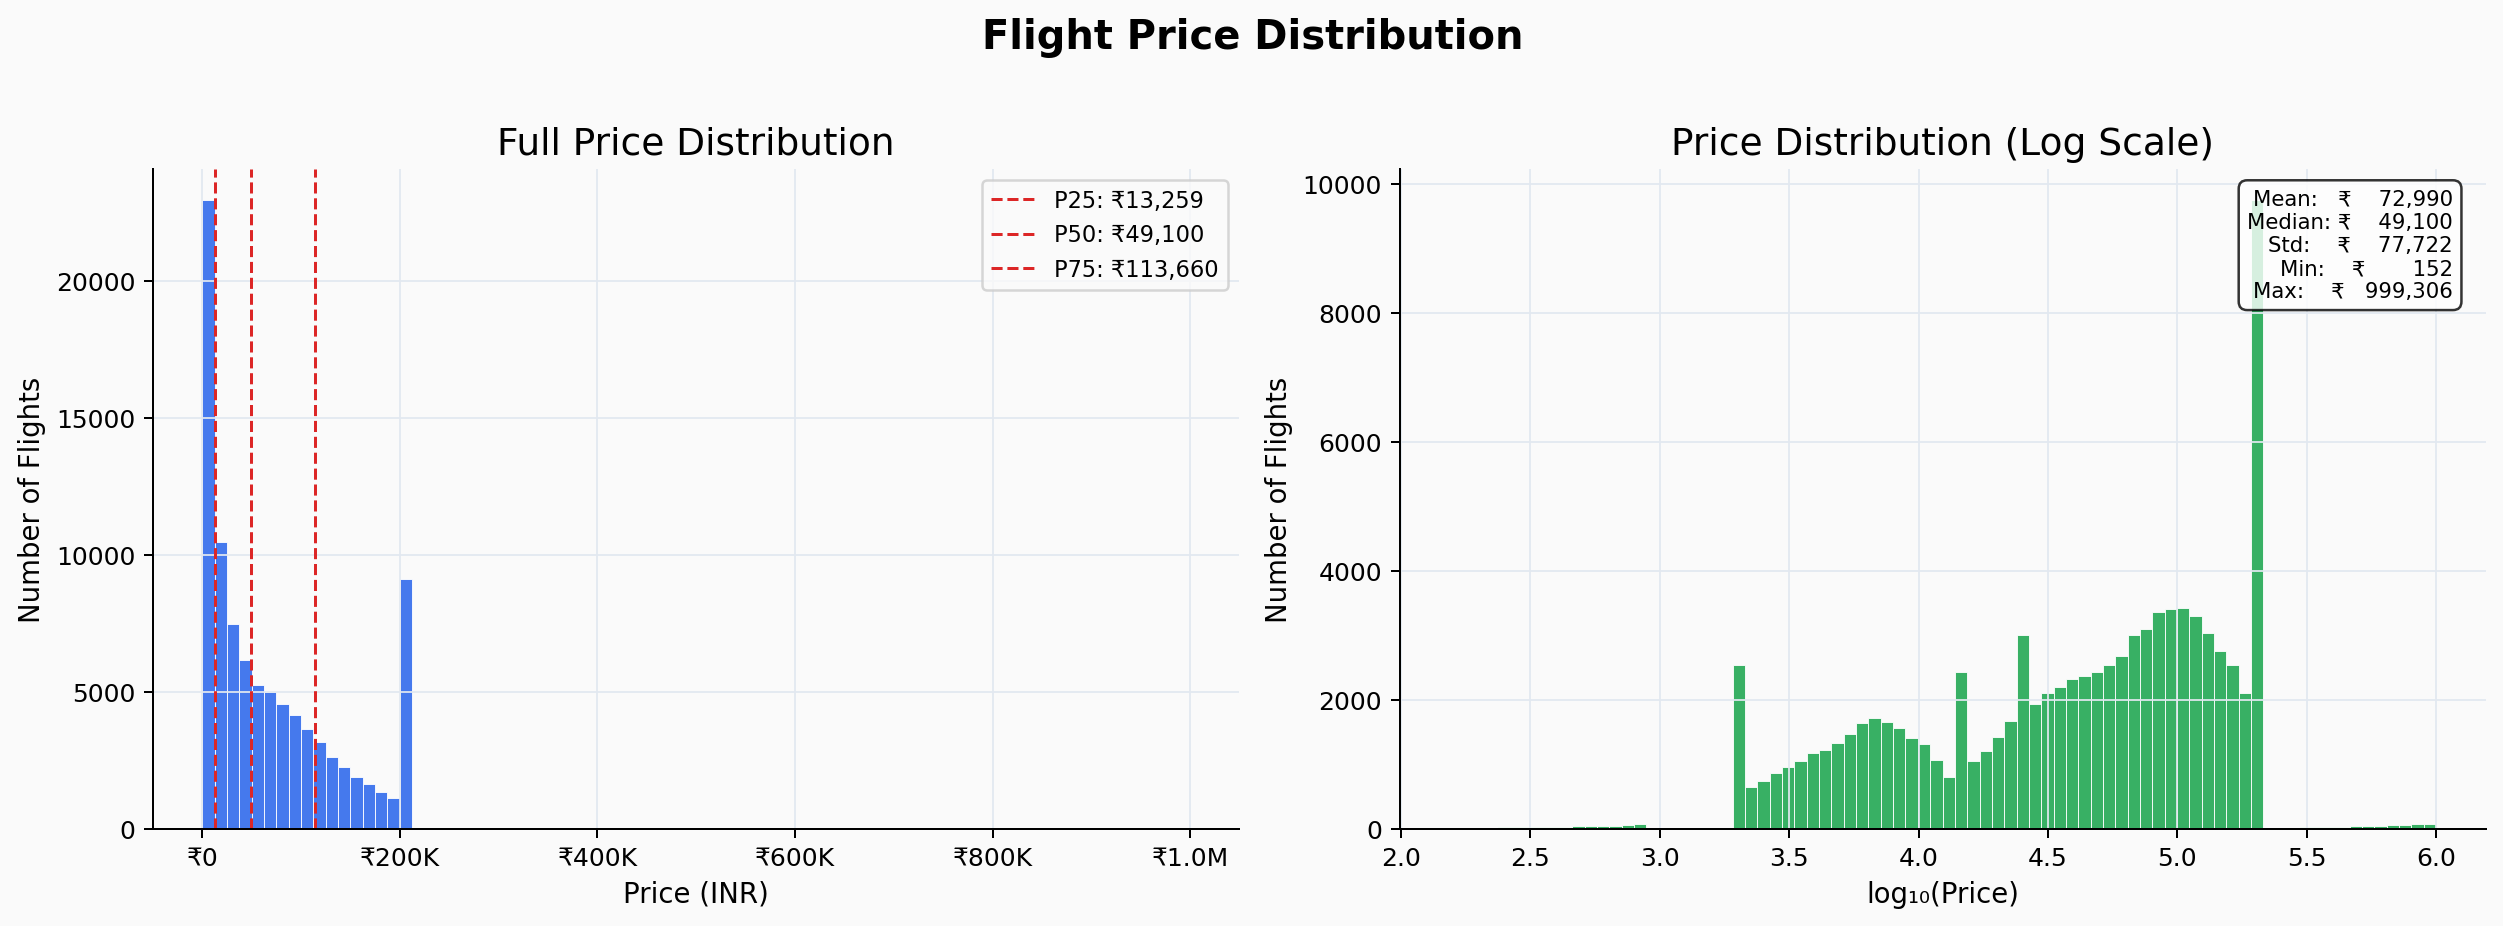

In [4]:
path = plot_price_distribution(df)
display(Image(filename=str(path)))

In [5]:
p25, p50, p75 = df['Price'].quantile([0.25, 0.50, 0.75])
print(f'Distribution is heavily right-skewed.')
print(f'  25th percentile : ₹{p25:>10,.0f}')
print(f'  Median (P50)    : ₹{p50:>10,.0f}')
print(f'  75th percentile : ₹{p75:>10,.0f}')
print(f'  Mean            : ₹{df["Price"].mean():>10,.0f}  (pulled by high-value outliers)')
print(f'  75% of flights cost less than ₹{p75:,.0f} — log scale reveals bi-modal structure.')

Distribution is heavily right-skewed.
  25th percentile : ₹    13,259
  Median (P50)    : ₹    49,100
  75th percentile : ₹   113,660
  Mean            : ₹    72,990  (pulled by high-value outliers)
  75% of flights cost less than ₹113,660 — log scale reveals bi-modal structure.


---
## 2 · Airline vs Price

  Saved → 02_airline_vs_price.png


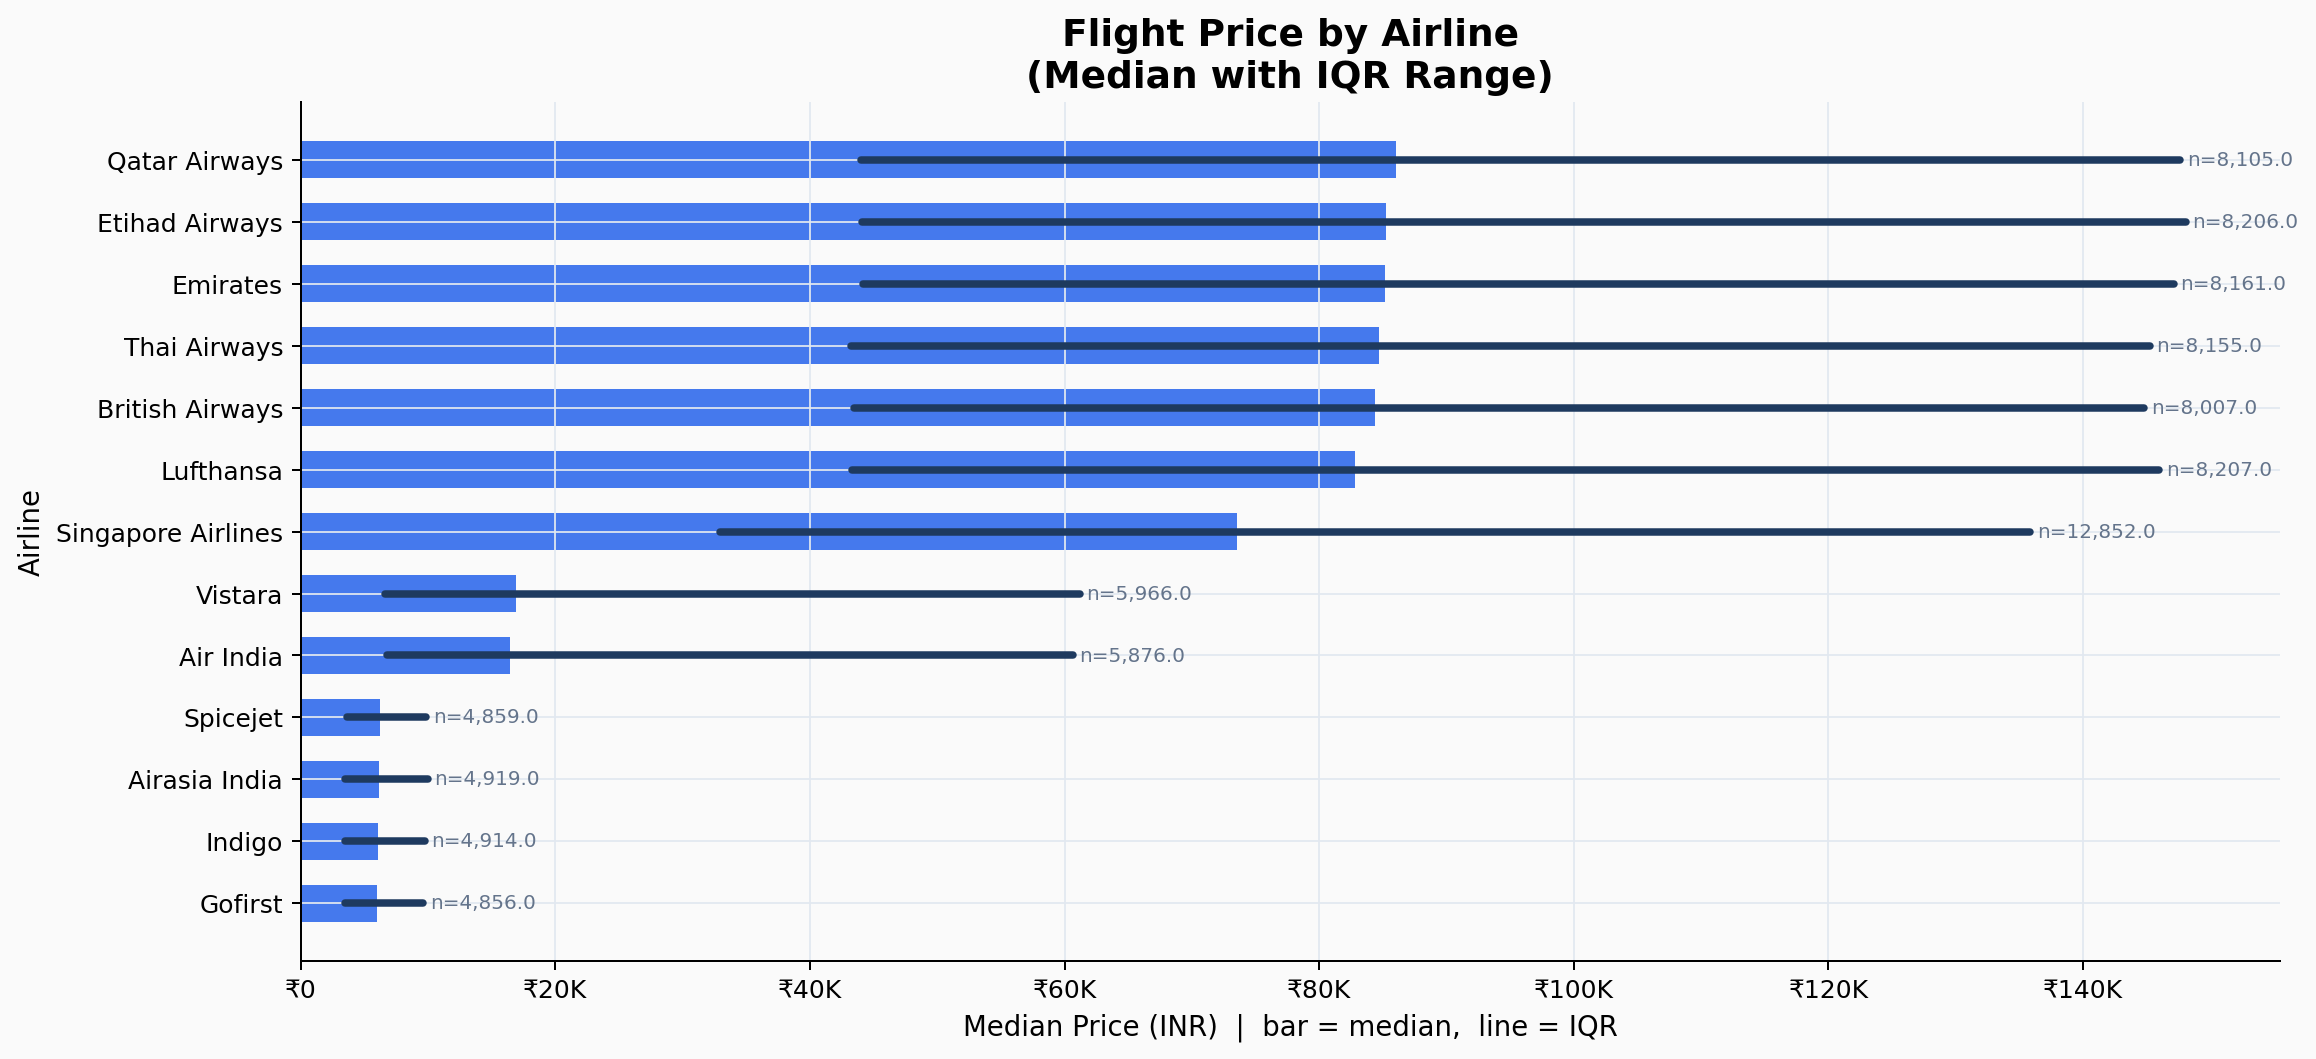

In [6]:
path = plot_airline_vs_price(df)
display(Image(filename=str(path)))

In [7]:
airline_med = df.groupby('Airline')['Price'].median().sort_values(ascending=False)
print('Median price by airline:')
for a, p in airline_med.items():
    print(f'  {a:<22}: ₹{p:>10,.0f}')
print(f'\nObservation: International carriers (Qatar, Etihad, Emirates) show ~14× higher median')
print(f'prices compared to domestic LCCs (GoFirst, IndiGo, AirAsia India).')
print(f'Ratio — Qatar / GoFirst : {airline_med["Qatar Airways"]/airline_med["Gofirst"]:.1f}×')

Median price by airline:
  Qatar Airways         : ₹    86,017
  Etihad Airways        : ₹    85,242
  Emirates              : ₹    85,199
  Thai Airways          : ₹    84,699
  British Airways       : ₹    84,376
  Lufthansa             : ₹    82,839
  Singapore Airlines    : ₹    73,582
  Vistara               : ₹    16,928
  Air India             : ₹    16,458
  Spicejet              : ₹     6,198
  Airasia India         : ₹     6,164
  Indigo                : ₹     6,073
  Gofirst               : ₹     5,975

Observation: International carriers (Qatar, Etihad, Emirates) show ~14× higher median
prices compared to domestic LCCs (GoFirst, IndiGo, AirAsia India).
Ratio — Qatar / GoFirst : 14.4×


---
## 3 · Travel Class vs Price

  Saved → 03_travel_class_vs_price.png


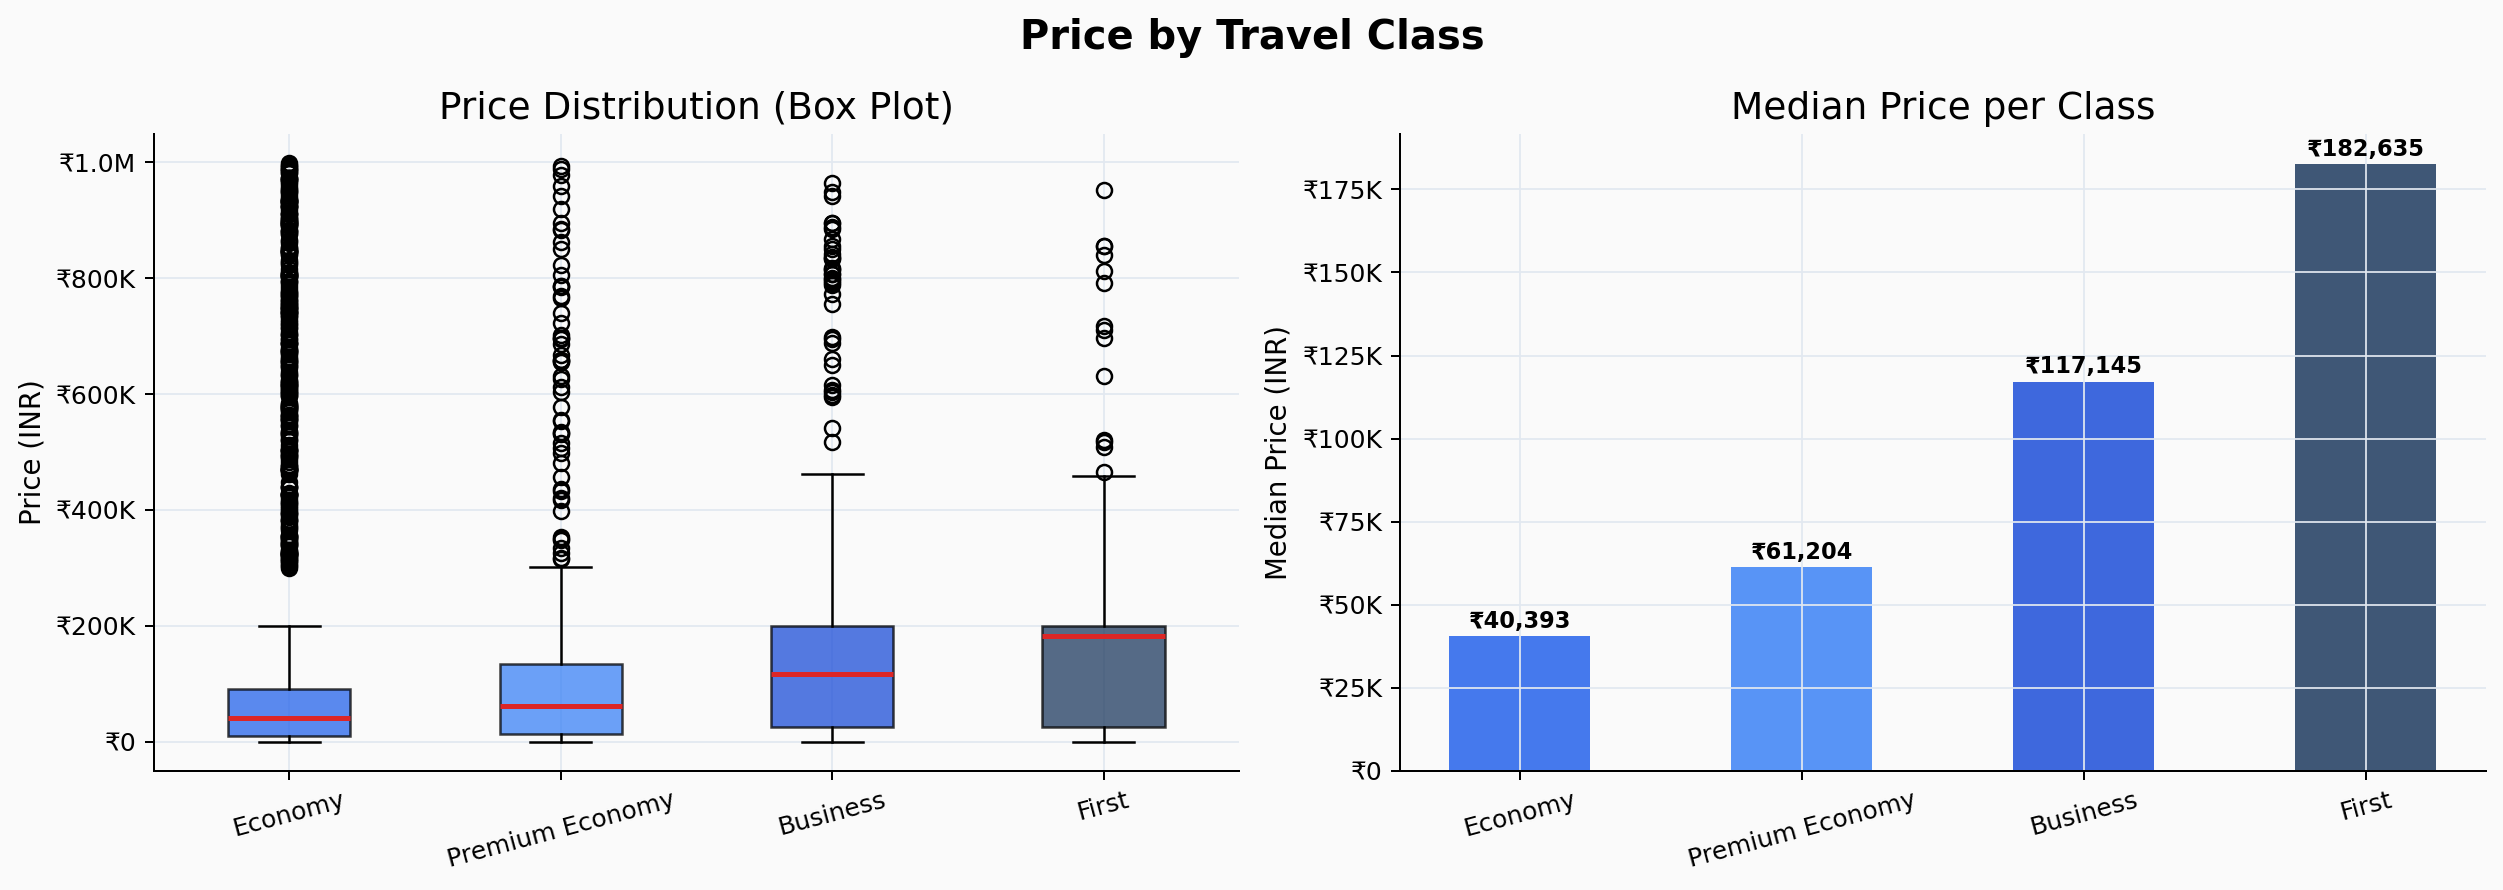

In [8]:
path = plot_travel_class_vs_price(df)
display(Image(filename=str(path)))

In [9]:
cls_med = df.groupby('Travel_Class')['Price'].median().sort_values(ascending=False)
print('Median price by class:')
for c, p in cls_med.items():
    print(f'  {c:<20}: ₹{p:>10,.0f}')
print(f'\nFirst class shows ₹{cls_med["First"]/cls_med["Economy"]:.1f}× the Economy median price.')
print(f'Travel class is one of the strongest categorical price differentiators in this dataset.')

Median price by class:
  First               : ₹   182,635
  Business            : ₹   117,145
  Premium Economy     : ₹    61,204
  Economy             : ₹    40,393

First class shows ₹4.5× the Economy median price.
Travel class is one of the strongest categorical price differentiators in this dataset.


---
## 4 · Total Stops vs Price

  Saved → 04_stops_vs_price.png


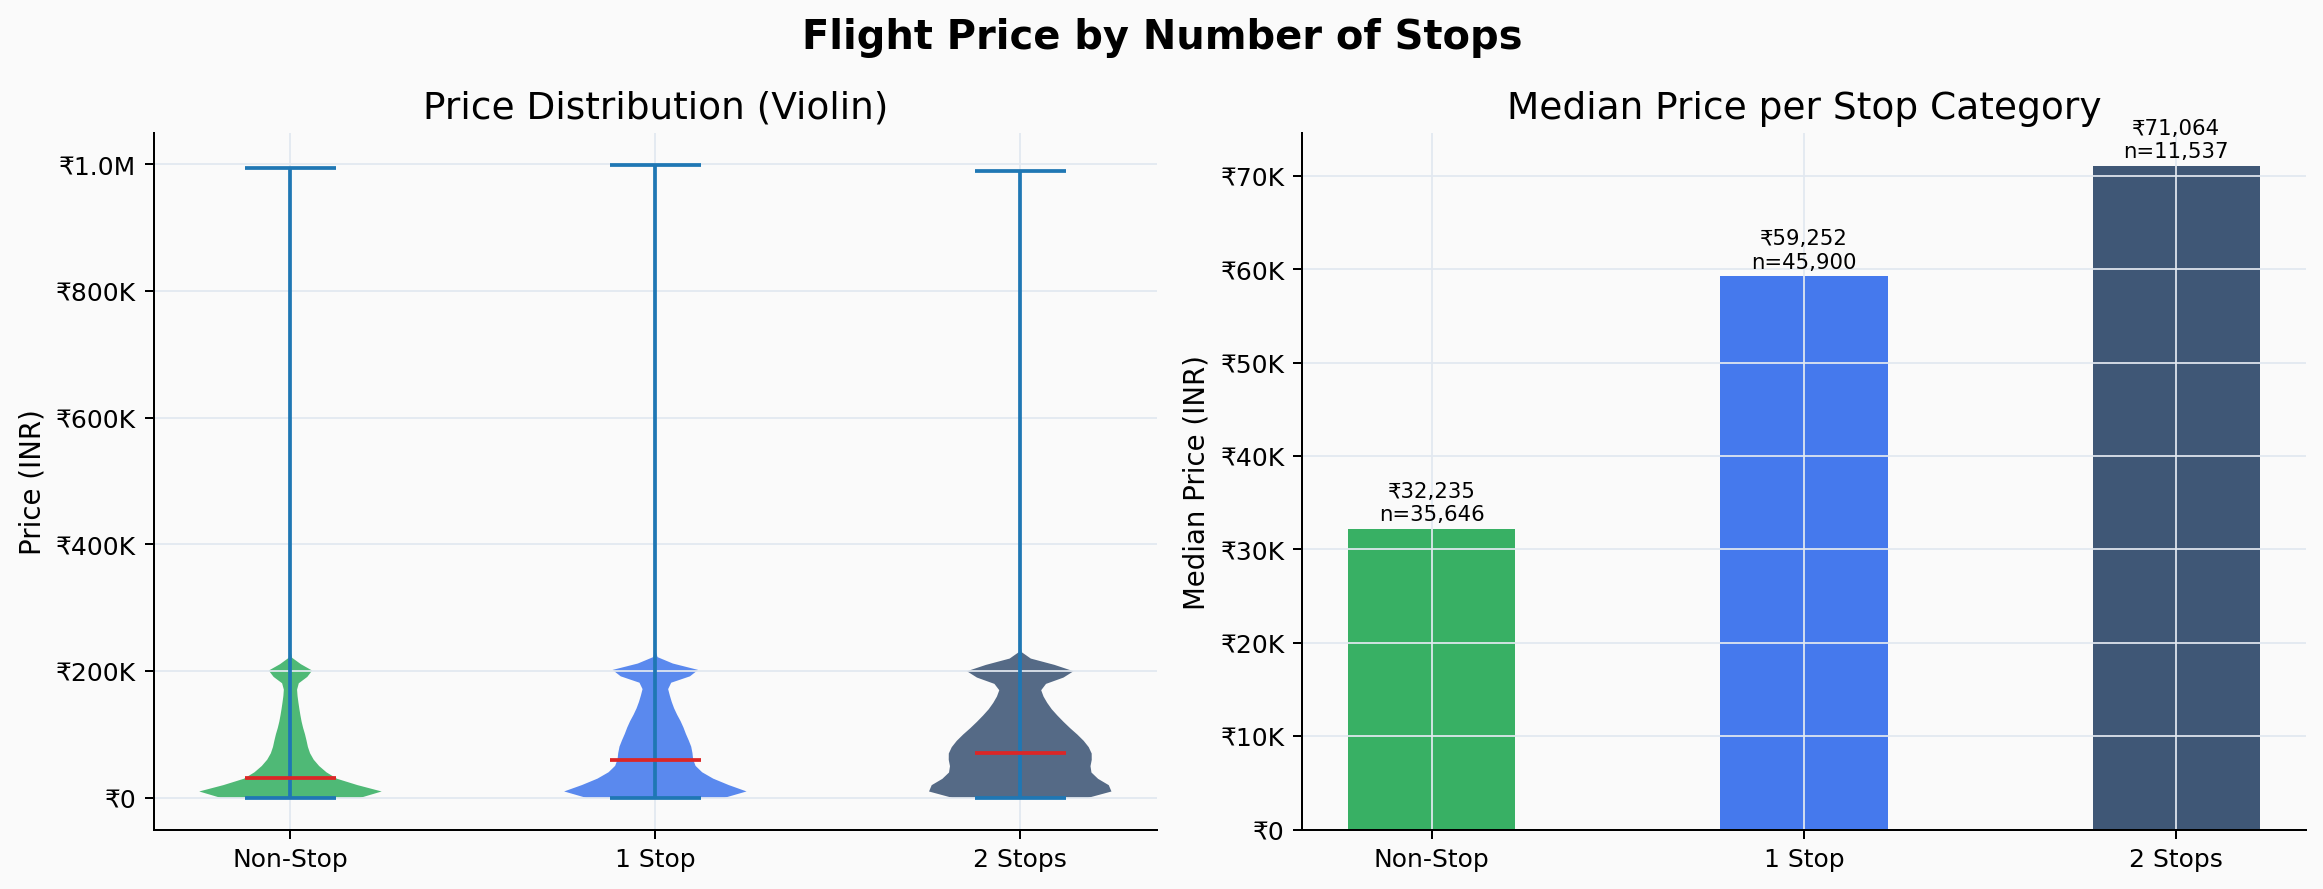

In [10]:
path = plot_stops_vs_price(df)
display(Image(filename=str(path)))

In [11]:
stops_med = df.groupby('Total_Stops_Numeric')['Price'].median().sort_index()
stop_lbl = {0.0:'Non-Stop', 1.0:'1 Stop', 2.0:'2 Stops'}
print('Median price by stops:')
for s, p in stops_med.items():
    print(f'  {stop_lbl.get(s, s):<12}: ₹{p:>10,.0f}')
print(f'\nObservation: More stops are associated with higher prices (r = {df["Total_Stops_Numeric"].corr(df["Price"]):.3f}).')
print('This likely reflects that connecting flights are predominantly long-haul international routes.')

Median price by stops:
  Non-Stop    : ₹    32,235
  1 Stop      : ₹    59,252
  2 Stops     : ₹    71,064

Observation: More stops are associated with higher prices (r = 0.113).
This likely reflects that connecting flights are predominantly long-haul international routes.


---
## 5 · Source & Destination vs Price

  Saved → 05_source_dest_vs_price.png


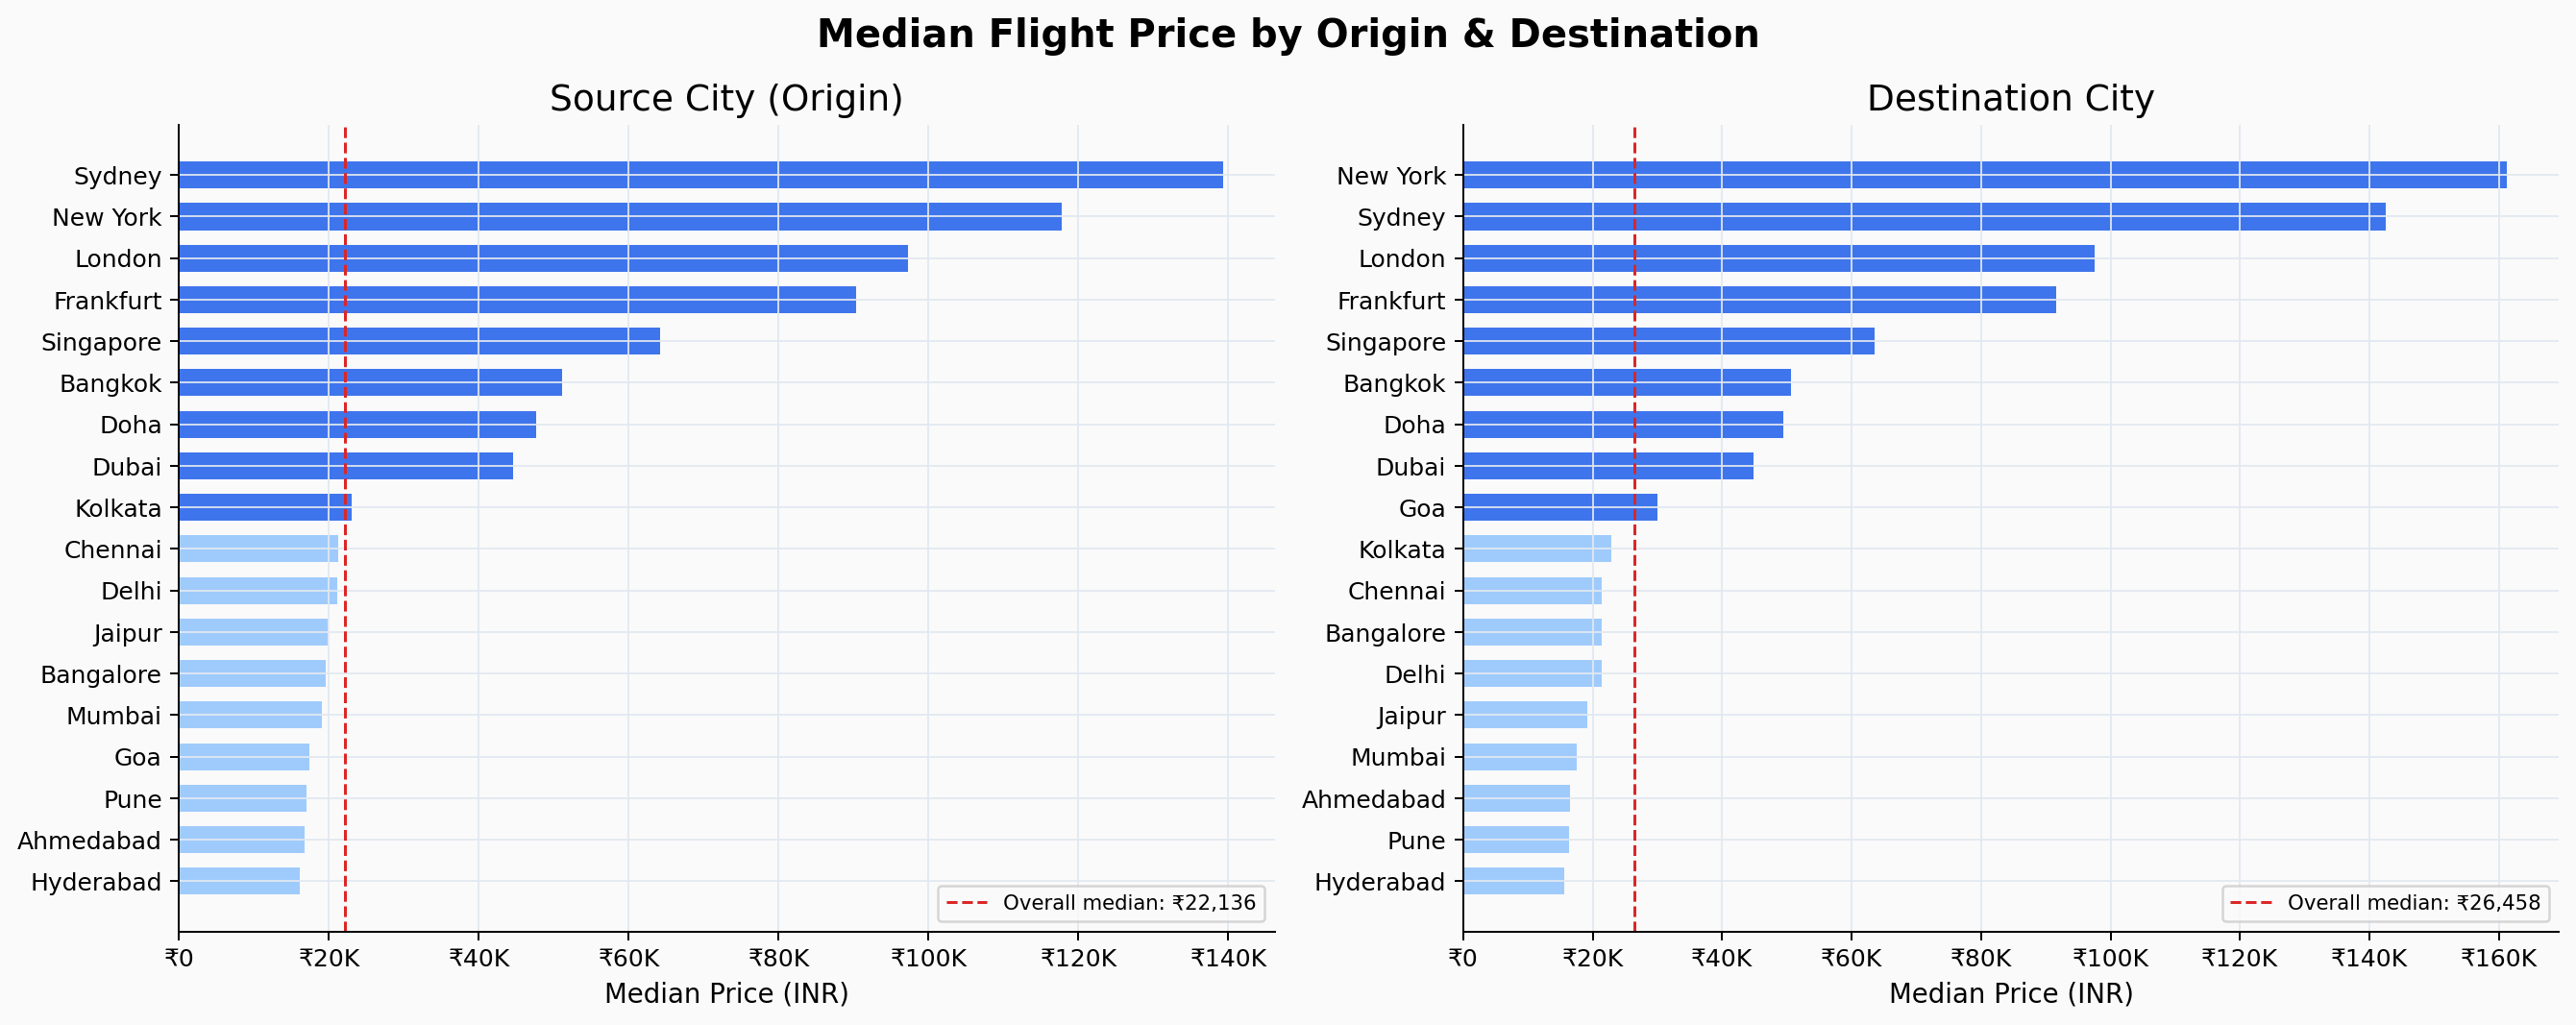

In [12]:
path = plot_source_dest_vs_price(df)
display(Image(filename=str(path)))

In [13]:
src_med = df.groupby('Source')['Price'].median().sort_values(ascending=False)
print('Top 5 highest-price origins:')
for city, p in src_med.head(5).items():
    print(f'  {city:<15}: ₹{p:>10,.0f}')
print('\nBottom 5 lowest-price origins:')
for city, p in src_med.tail(5).items():
    print(f'  {city:<15}: ₹{p:>10,.0f}')
print(f'\nSydney and New York origins are associated with the highest median prices.')
print(f'Hyderabad, Ahmedabad, and Pune origins show the lowest median prices.')

Top 5 highest-price origins:
  Sydney         : ₹   139,265
  New York       : ₹   117,757
  London         : ₹    97,205
  Frankfurt      : ₹    90,333
  Singapore      : ₹    64,189

Bottom 5 lowest-price origins:
  Mumbai         : ₹    19,089
  Goa            : ₹    17,387
  Pune           : ₹    17,025
  Ahmedabad      : ₹    16,764
  Hyderabad      : ₹    16,127

Sydney and New York origins are associated with the highest median prices.
Hyderabad, Ahmedabad, and Pune origins show the lowest median prices.


---
## 6 · Duration vs Price

  Saved → 06_duration_vs_price.png


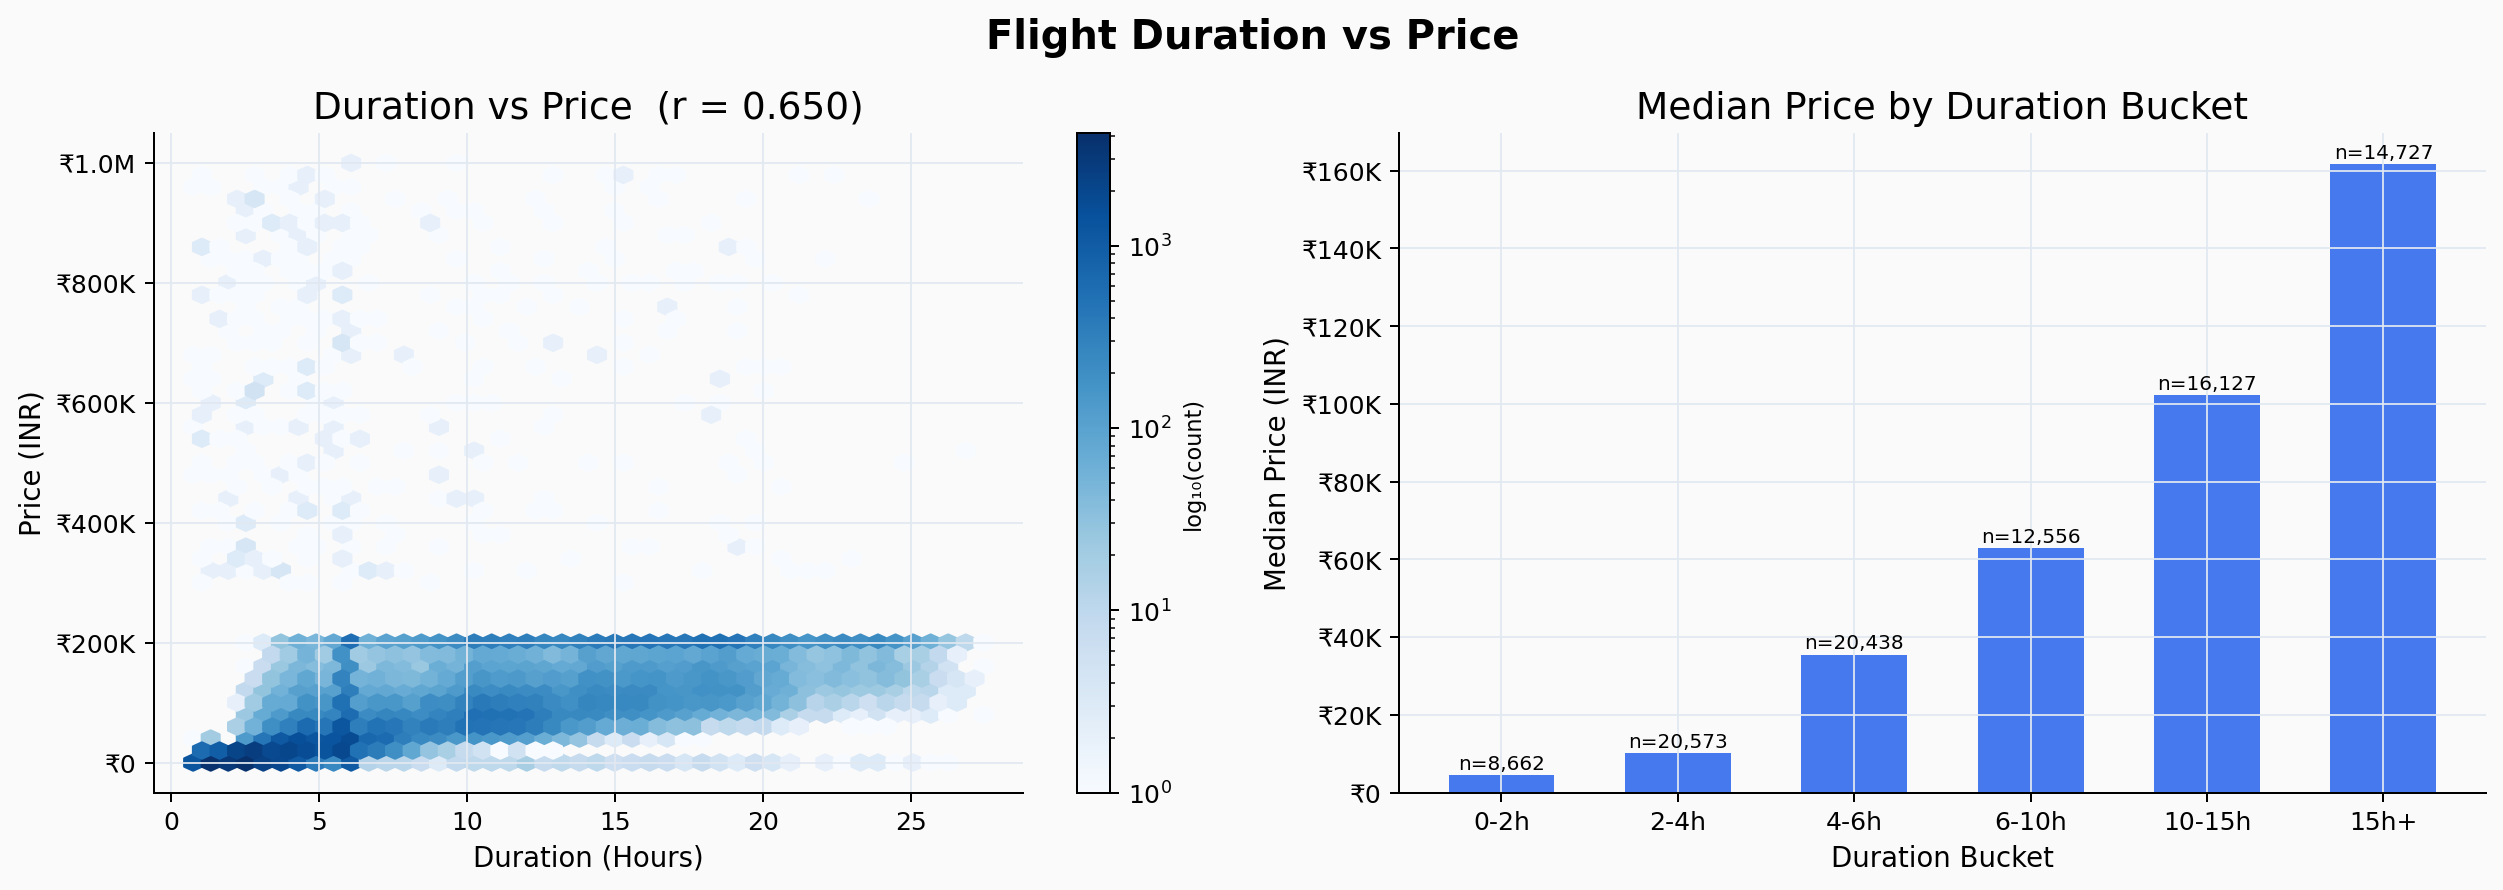

In [14]:
path = plot_duration_vs_price(df)
display(Image(filename=str(path)))

In [15]:
r = df['Duration_Minutes'].corr(df['Price'])
df2 = df.copy()
df2['Duration_Bin'] = pd.cut(df2['Duration_Minutes']/60,
    bins=[0,2,4,6,10,15,28],
    labels=['0-2h','2-4h','4-6h','6-10h','10-15h','15h+'])
bin_med = df2.groupby('Duration_Bin', observed=True)['Price'].median()
print(f'Pearson r (Duration_Minutes vs Price): {r:.4f}')
print('\nMedian price by duration bucket:')
for b, p in bin_med.items():
    print(f'  {str(b):<8}: ₹{p:>10,.0f}')
print(f'\nStrong positive association — longer flights show significantly higher prices.')
print(f'Duration is one of the two strongest numerical predictors (r ≈ 0.65).')

Pearson r (Duration_Minutes vs Price): 0.6498

Median price by duration bucket:
  0-2h    : ₹     4,538
  2-4h    : ₹    10,064
  4-6h    : ₹    35,497
  6-10h   : ₹    63,000
  10-15h  : ₹   102,270
  15h+    : ₹   161,638

Strong positive association — longer flights show significantly higher prices.
Duration is one of the two strongest numerical predictors (r ≈ 0.65).


---
## 7 · Departure & Arrival Time vs Price

  Saved → 07_time_vs_price.png


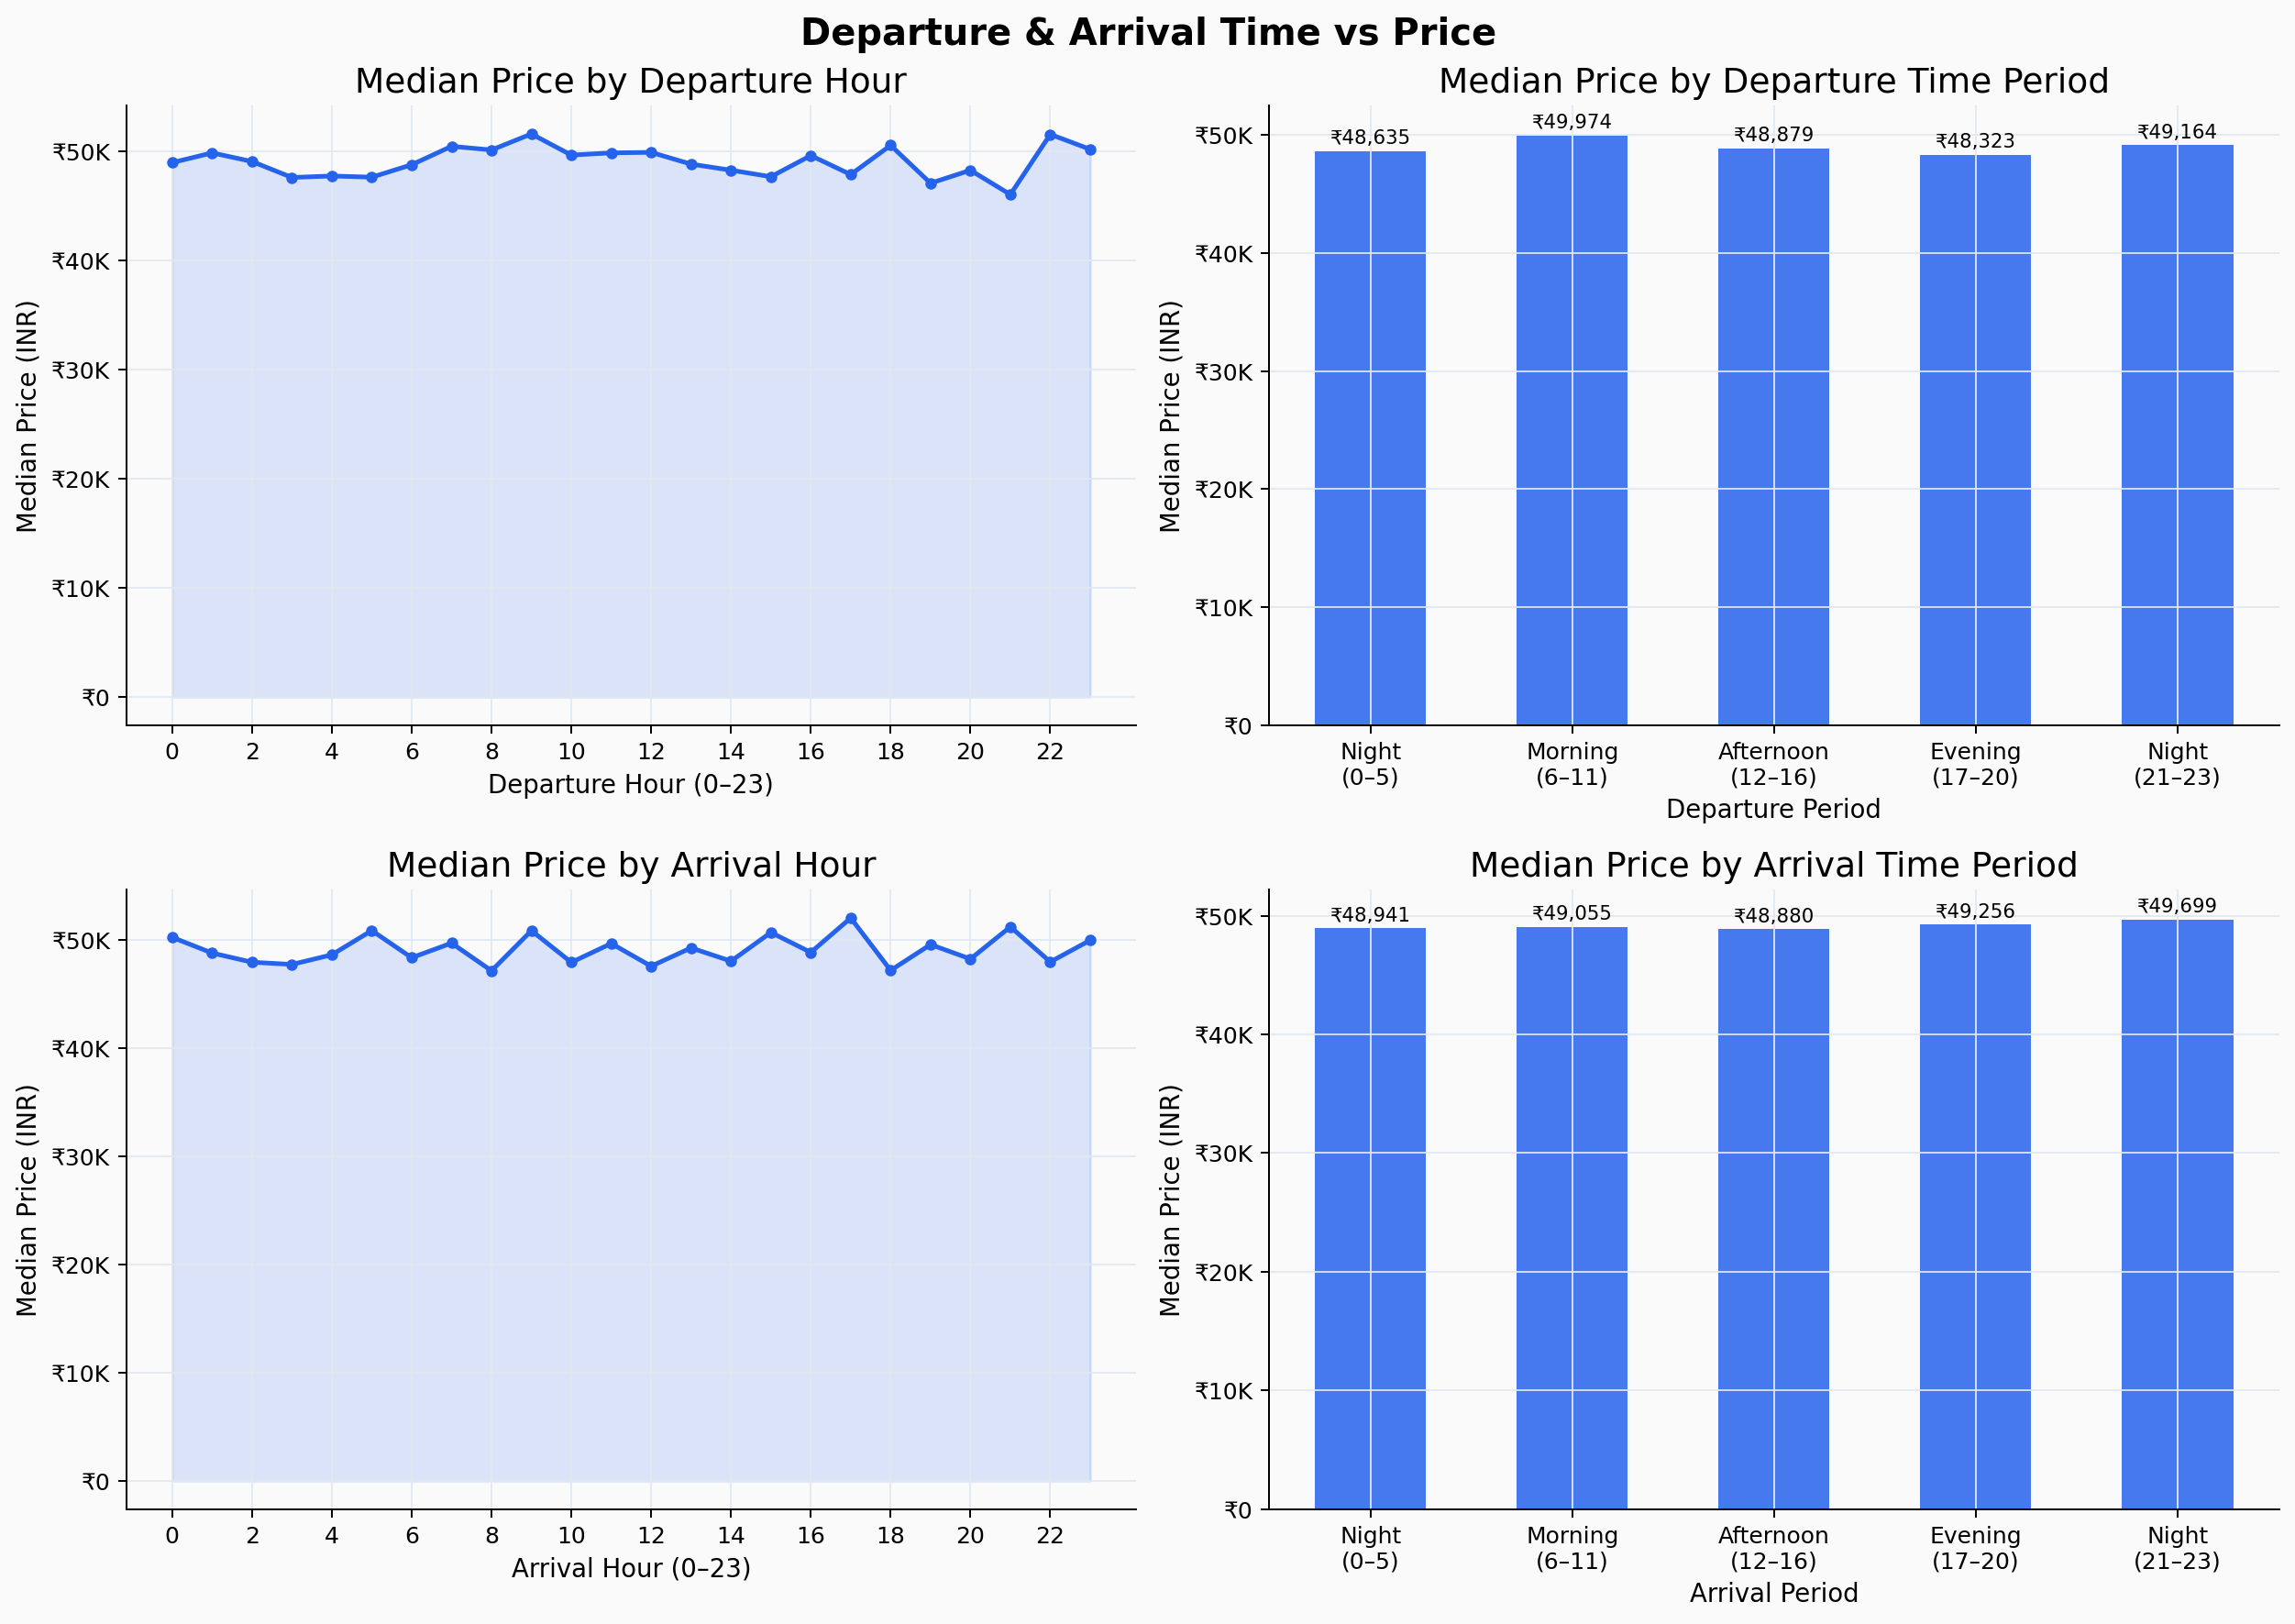

In [16]:
path = plot_time_vs_price(df)
display(Image(filename=str(path)))

In [17]:
df2 = df.copy()
df2['Dep_Hour'] = (df2['Departure_Time_Minutes'] / 60).astype(int) % 24
hourly_dep = df2.groupby('Dep_Hour')['Price'].median()
print(f'Departure Time correlation with Price: r = {df["Departure_Time_Minutes"].corr(df["Price"]):.4f}')
print(f'Peak pricing hour (departure): {hourly_dep.idxmax()}:00  — ₹{hourly_dep.max():,.0f}')
print(f'Lowest pricing hour (departure): {hourly_dep.idxmin()}:00  — ₹{hourly_dep.min():,.0f}')
print(f'\nObservation: Departure time shows minimal correlation (r ≈ 0.00) with Price.')
print('Small intra-day fluctuations exist but are unlikely to be a meaningful predictor.')

Departure Time correlation with Price: r = -0.0007
Peak pricing hour (departure): 9:00  — ₹51,604
Lowest pricing hour (departure): 21:00  — ₹46,050

Observation: Departure time shows minimal correlation (r ≈ 0.00) with Price.
Small intra-day fluctuations exist but are unlikely to be a meaningful predictor.


---
## 8 · Top Routes vs Price

  Saved → 08_routes_vs_price.png


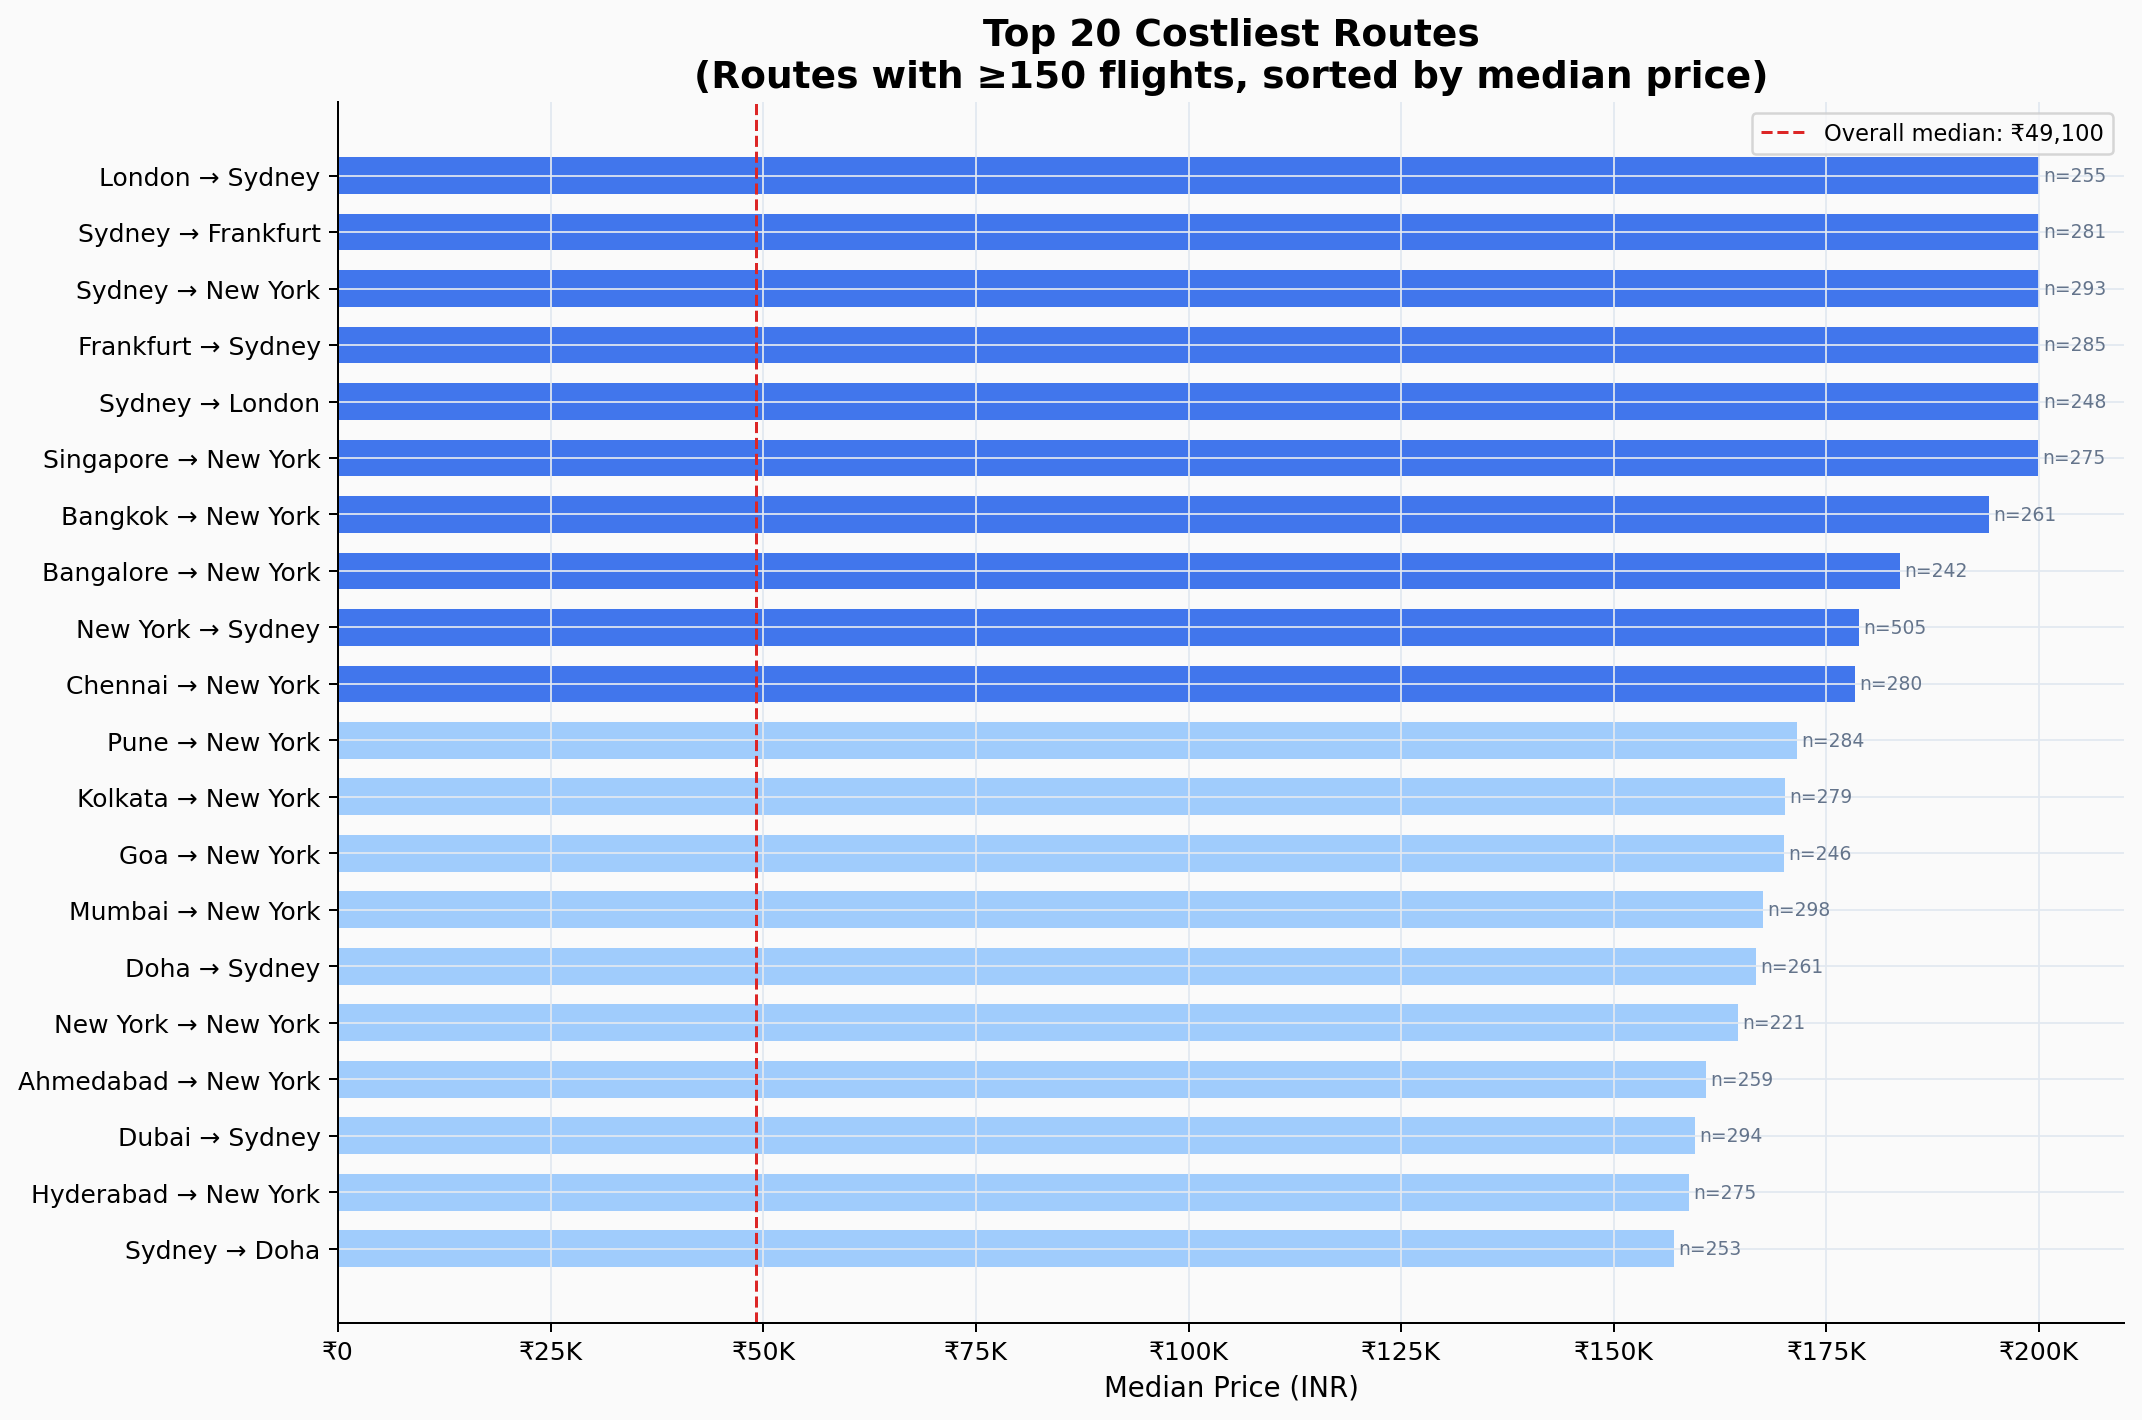

In [18]:
path = plot_routes_vs_price(df)
display(Image(filename=str(path)))

In [19]:
df2 = df.copy()
df2['Route'] = df2['Source'] + ' → ' + df2['Destination']
route_stats = (df2.groupby('Route')['Price']
    .agg(median='median', count='count')
    .query('count >= 150')
    .sort_values('median', ascending=False)
    .head(10))
print('Top 10 costliest routes (≥150 flights):')
for route, row in route_stats.iterrows():
    print(f'  {route:<35}: ₹{row["median"]:>10,.0f}  (n={row["count"]:,})')
print('\nAll top routes involve intercontinental city pairs (Sydney, New York, London).')

Top 10 costliest routes (≥150 flights):
  Frankfurt → Sydney                 : ₹   200,000  (n=285.0)
  Sydney → New York                  : ₹   200,000  (n=293.0)
  London → Sydney                    : ₹   200,000  (n=255.0)
  Sydney → London                    : ₹   200,000  (n=248.0)
  Sydney → Frankfurt                 : ₹   200,000  (n=281.0)
  Singapore → New York               : ₹   199,867  (n=275.0)
  Bangkok → New York                 : ₹   194,106  (n=261.0)
  Bangalore → New York               : ₹   183,658  (n=242.0)
  New York → Sydney                  : ₹   178,840  (n=505.0)
  Chennai → New York                 : ₹   178,350  (n=280.0)

All top routes involve intercontinental city pairs (Sydney, New York, London).


---
## 9 · Correlation Heatmap

  Saved → 09_correlation_heatmap.png


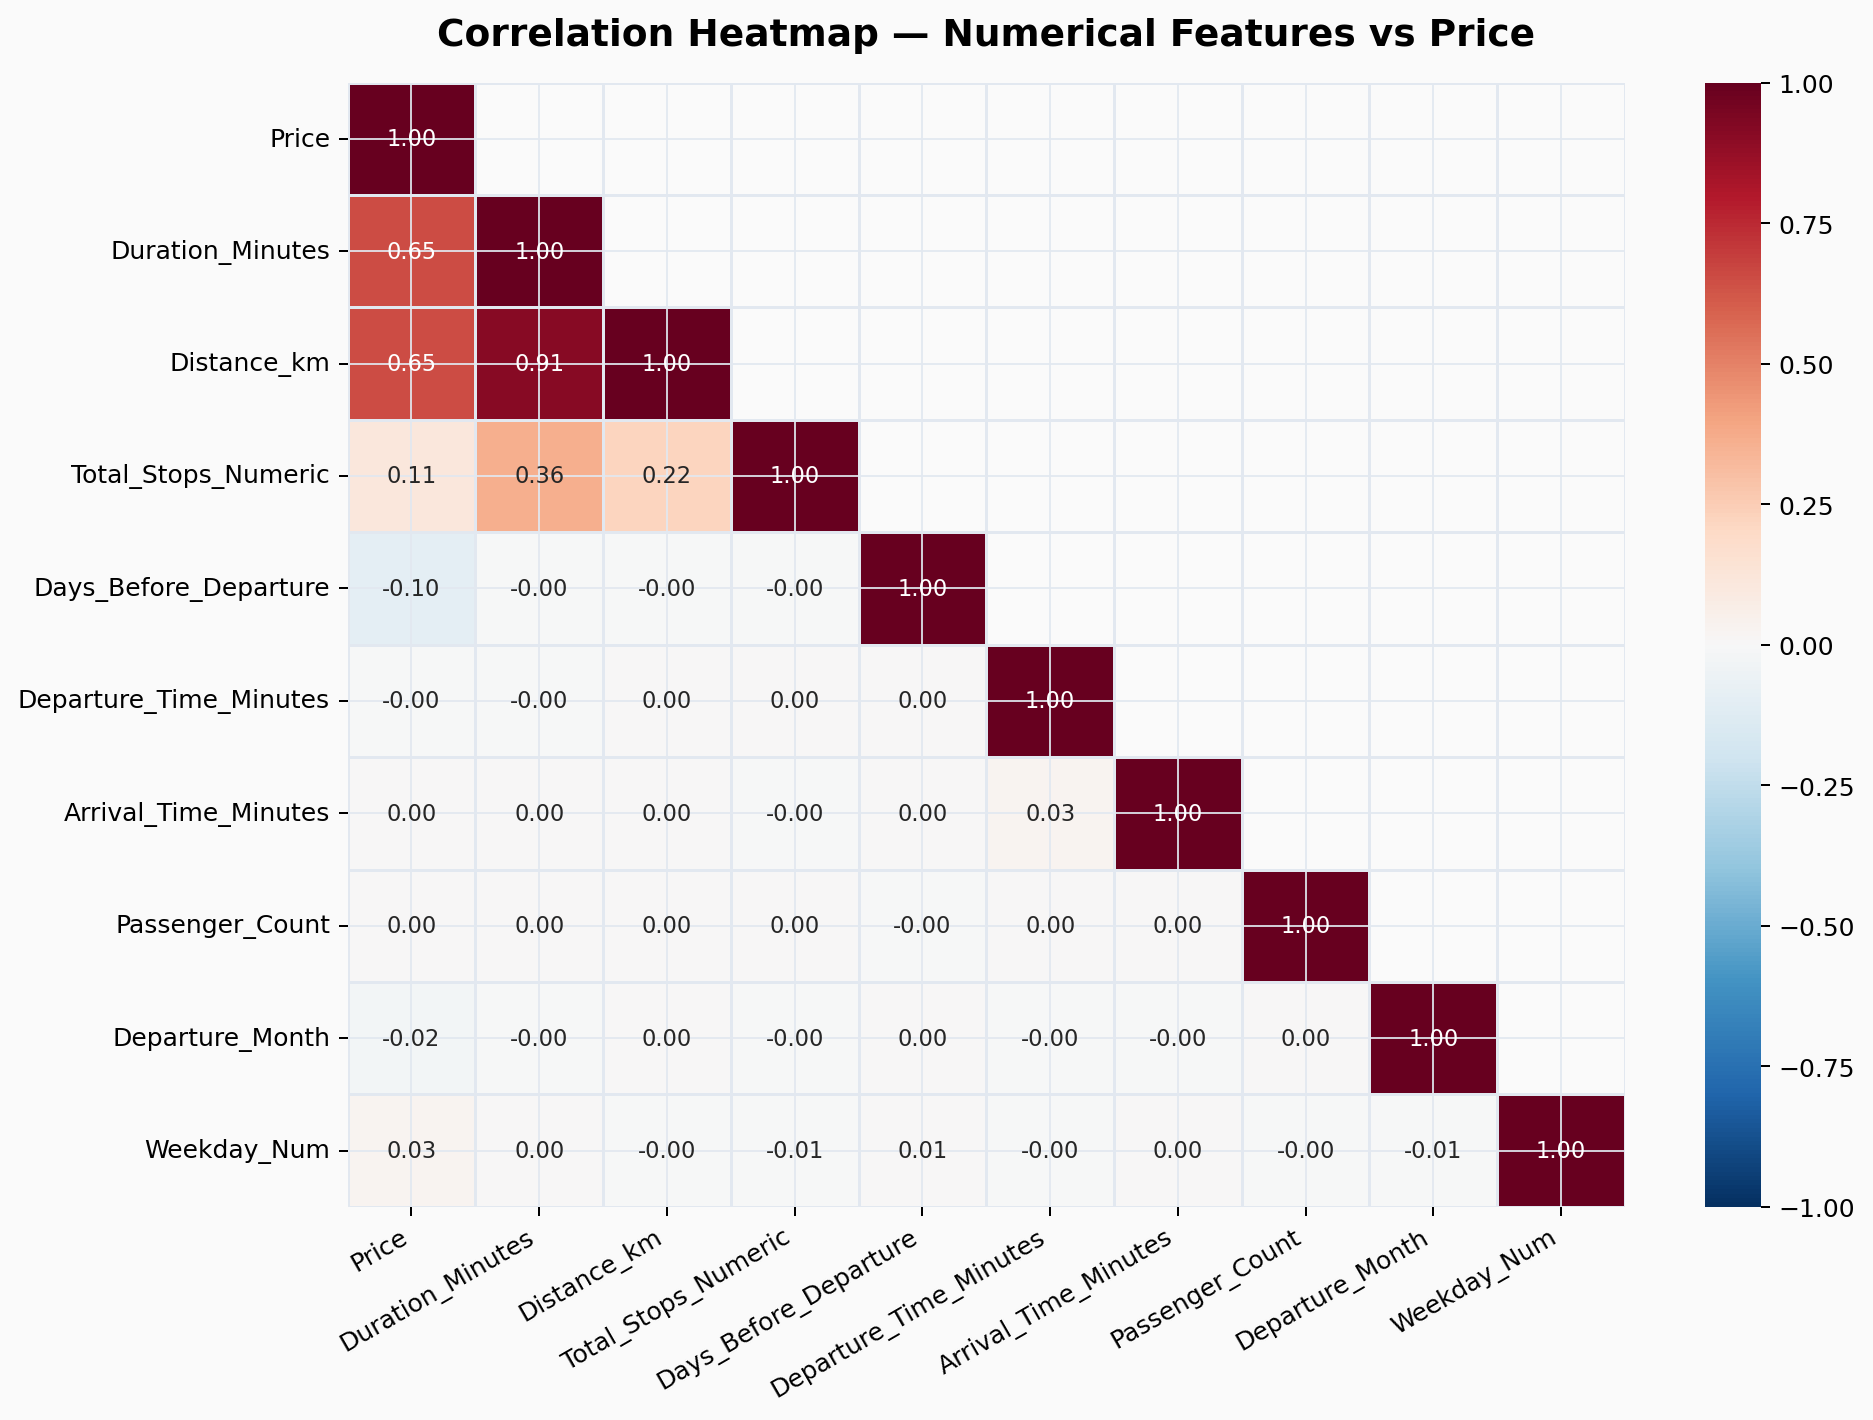

In [20]:
path = plot_correlation_heatmap(df)
display(Image(filename=str(path)))

In [21]:
num_cols = ['Price','Duration_Minutes','Distance_km','Total_Stops_Numeric',
            'Days_Before_Departure','Departure_Time_Minutes',
            'Arrival_Time_Minutes','Passenger_Count','Departure_Month','Weekday_Num']
corr_price = df[num_cols].corr()['Price'].sort_values(ascending=False)
print('Correlation with Price (all numerical features):')
for col, r in corr_price.items():
    bar = '█' * int(abs(r) * 20)
    sign = '+' if r >= 0 else '-'
    print(f'  {col:<35}: {sign}{abs(r):.4f}  {bar}')
print('\nStrongest predictors: Distance_km (r=0.65) and Duration_Minutes (r=0.65).')
print('Days_Before_Departure shows mild negative association (r≈-0.10).')

Correlation with Price (all numerical features):
  Price                              : +1.0000  ████████████████████
  Distance_km                        : +0.6521  █████████████
  Duration_Minutes                   : +0.6498  ████████████
  Total_Stops_Numeric                : +0.1127  ██
  Weekday_Num                        : +0.0266  
  Passenger_Count                    : +0.0043  
  Arrival_Time_Minutes               : +0.0008  
  Departure_Time_Minutes             : -0.0007  
  Departure_Month                    : -0.0237  
  Days_Before_Departure              : -0.0957  █

Strongest predictors: Distance_km (r=0.65) and Duration_Minutes (r=0.65).
Days_Before_Departure shows mild negative association (r≈-0.10).


---
## 10 · Price by Calendar (Month & Weekday)

  Saved → 10_price_by_calendar.png


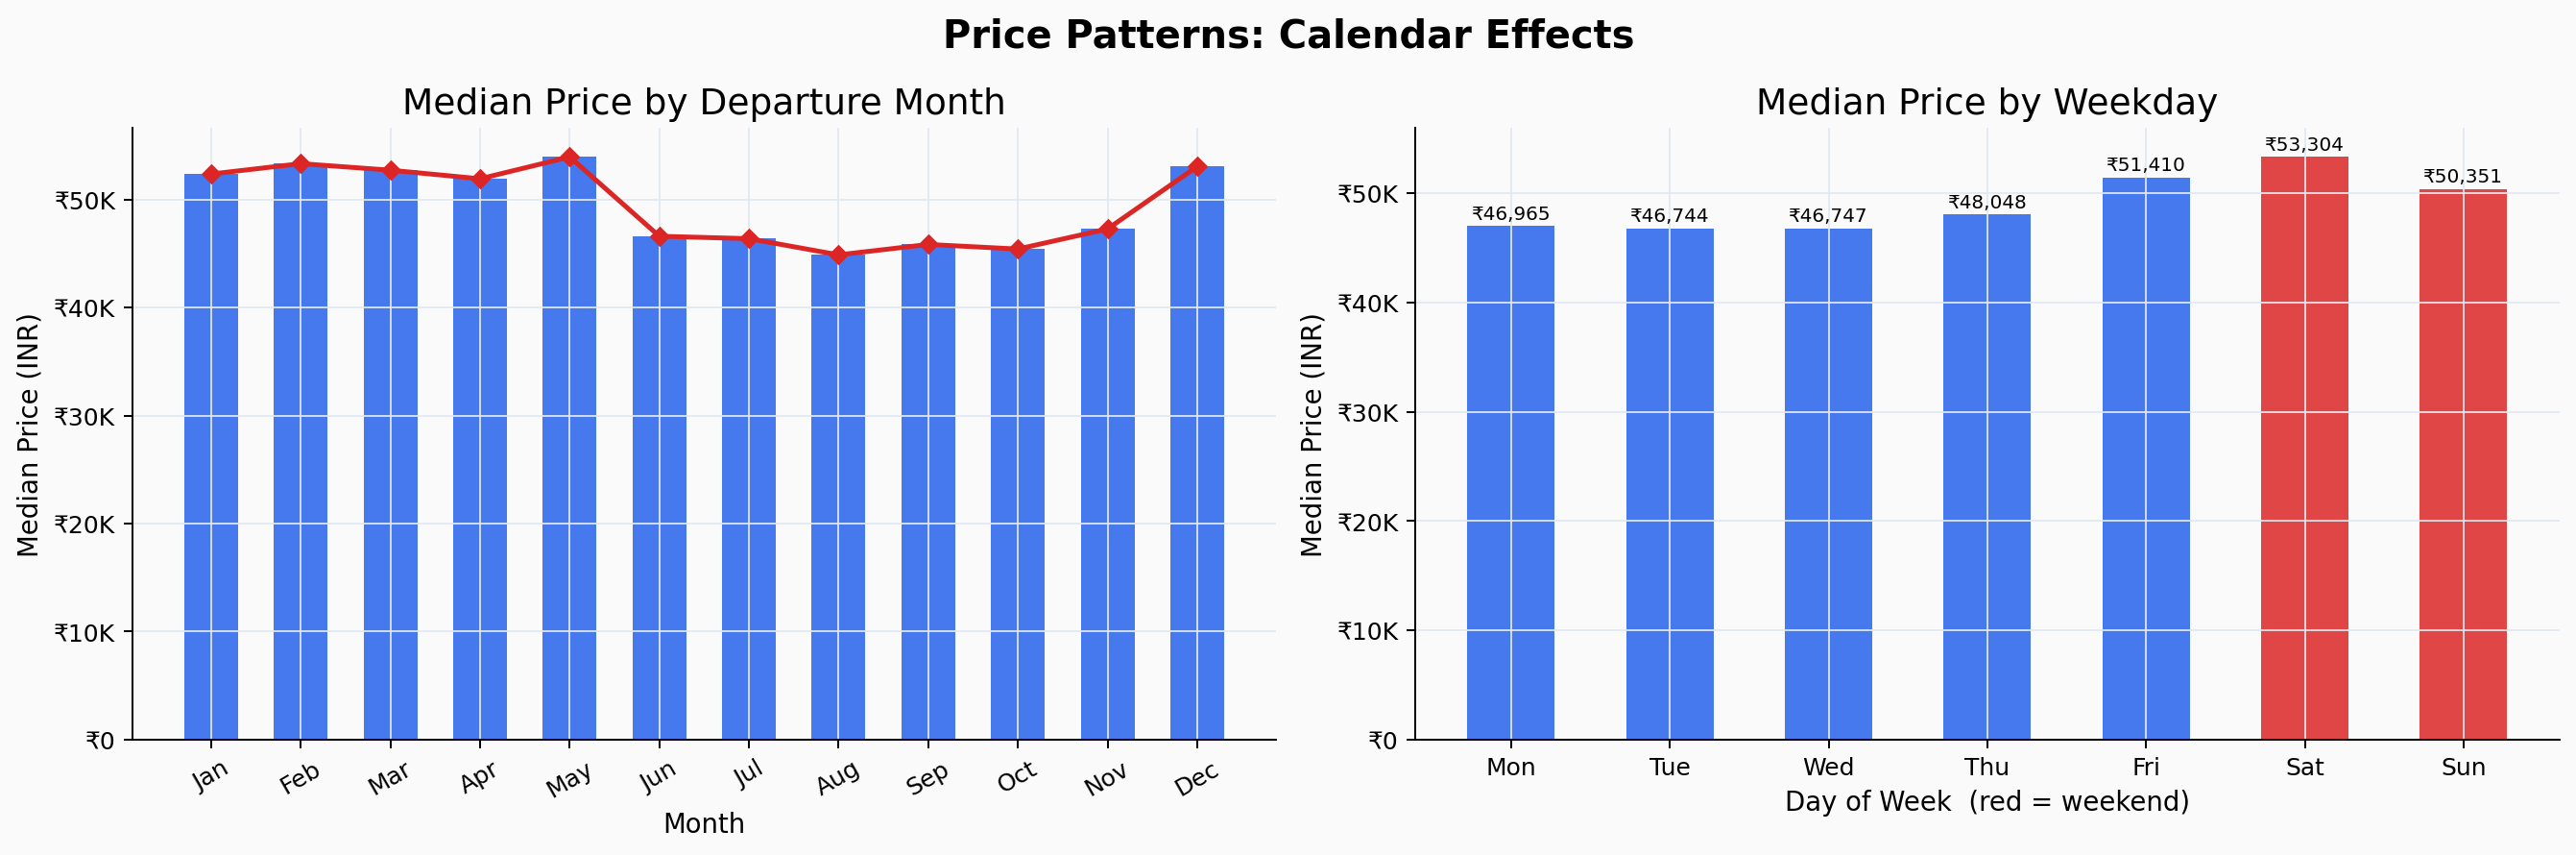

In [22]:
path = plot_price_by_calendar(df)
display(Image(filename=str(path)))

In [23]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df.groupby('Departure_Month')['Price'].median()
print('Median price by month:')
for m, p in monthly.items():
    print(f'  {month_map[int(m)]}: ₹{p:>10,.0f}')
print(f'\nHighest: {month_map[int(monthly.idxmax())]} (₹{monthly.max():,.0f})  '
      f'Lowest: {month_map[int(monthly.idxmin())]} (₹{monthly.min():,.0f})')
print(f'Monthly spread: ₹{monthly.max()-monthly.min():,.0f} — moderate variation.')

day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
weekday = df.groupby('Weekday_Num')['Price'].median()
print('\nMedian price by weekday:')
for d, p in weekday.items():
    print(f'  {day_map[int(d)]}: ₹{p:>10,.0f}')
print(f'\nSaturday/Friday show slightly higher prices vs midweek — small weekend premium pattern.')

Median price by month:
  Jan: ₹    52,354
  Feb: ₹    53,312
  Mar: ₹    52,707
  Apr: ₹    51,911
  May: ₹    53,935
  Jun: ₹    46,594
  Jul: ₹    46,368
  Aug: ₹    44,871
  Sep: ₹    45,833
  Oct: ₹    45,408
  Nov: ₹    47,267
  Dec: ₹    53,050

Highest: May (₹53,935)  Lowest: Aug (₹44,871)
Monthly spread: ₹9,063 — moderate variation.

Median price by weekday:
  Mon: ₹    46,965
  Tue: ₹    46,744
  Wed: ₹    46,747
  Thu: ₹    48,048
  Fri: ₹    51,410
  Sat: ₹    53,304
  Sun: ₹    50,351

Saturday/Friday show slightly higher prices vs midweek — small weekend premium pattern.


---
## 11 · Season & Booking Channel vs Price

  Saved → 11_season_channel_vs_price.png


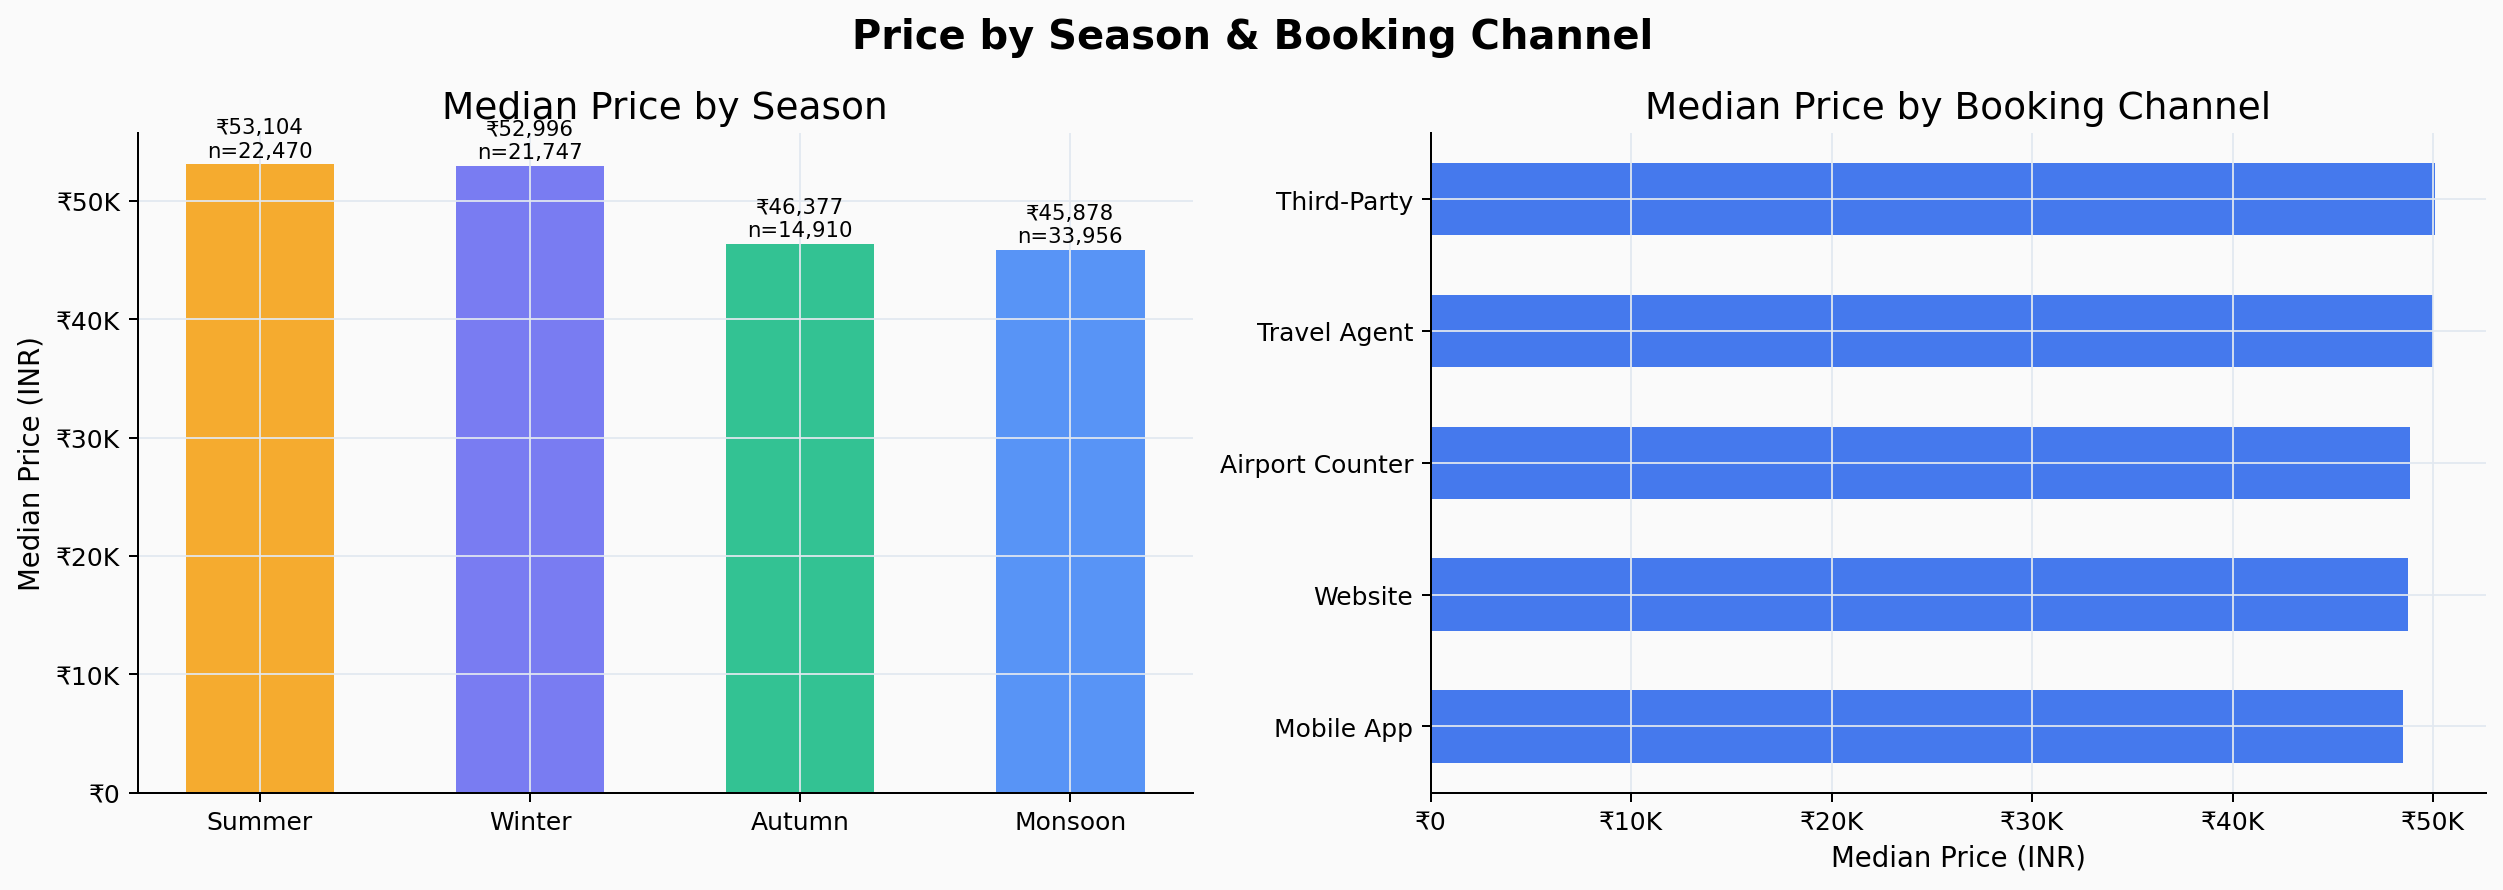

In [24]:
path = plot_season_channel_vs_price(df)
display(Image(filename=str(path)))

In [25]:
print('Season vs Price:')
print(df.groupby('Season')['Price'].median().sort_values(ascending=False)
        .apply(lambda x: f'₹{x:,.0f}'))
print('\nBooking Channel vs Price:')
print(df.groupby('Booking_Channel')['Price'].median().sort_values(ascending=False)
        .apply(lambda x: f'₹{x:,.0f}'))
print('\nSummer and Winter show higher median prices than Monsoon — seasonal demand pattern.')
print('Booking channel shows minor differences — channels likely serve overlapping flight types.')

Season vs Price:
Season
Summer     ₹53,104
Winter     ₹52,996
Autumn     ₹46,377
Monsoon    ₹45,878
Name: Price, dtype: object

Booking Channel vs Price:
Booking_Channel
Third-Party        ₹50,110
Travel Agent       ₹50,006
Airport Counter    ₹48,858
Website            ₹48,726
Mobile App         ₹48,514
Name: Price, dtype: object

Summer and Winter show higher median prices than Monsoon — seasonal demand pattern.
Booking channel shows minor differences — channels likely serve overlapping flight types.


---
## 12 · Days Before Departure vs Price (Lead Time)

  Saved → 12_days_before_departure.png


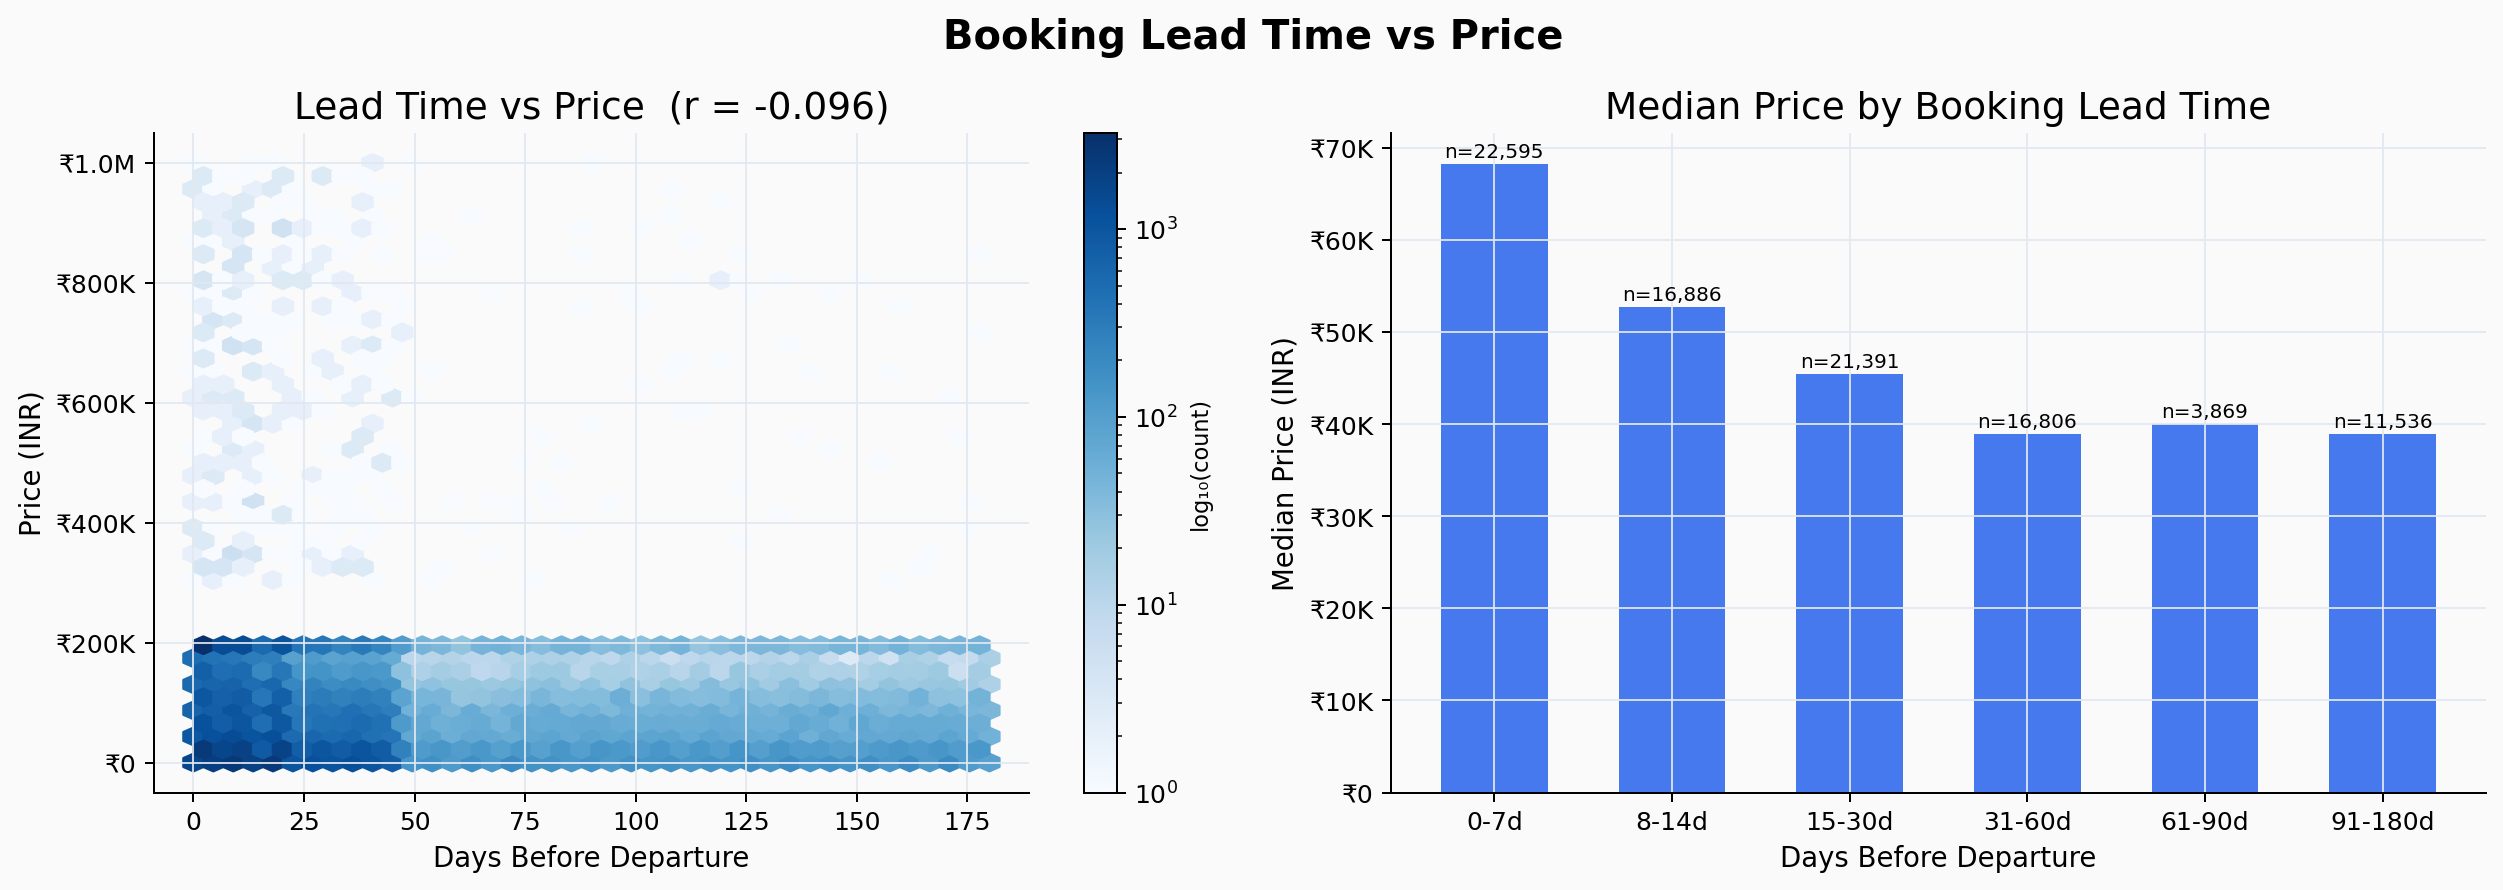

In [26]:
path = plot_days_before_departure(df)
display(Image(filename=str(path)))

In [27]:
r = df['Days_Before_Departure'].corr(df['Price'])
df2 = df.copy()
df2['Lead_Bin'] = pd.cut(df2['Days_Before_Departure'],
    bins=[-1,7,14,30,60,90,180],
    labels=['0-7d','8-14d','15-30d','31-60d','61-90d','91-180d'])
lead_med = df2.groupby('Lead_Bin', observed=True)['Price'].median()
print(f'Correlation with Price: r = {r:.4f}')
print('\nMedian price by booking lead time:')
for b, p in lead_med.items():
    print(f'  {str(b):<10}: ₹{p:>10,.0f}')
print('\nLast-minute bookings (0-7d) show a mild price premium pattern in this dataset.')

Correlation with Price: r = -0.0957

Median price by booking lead time:
  0-7d      : ₹    68,226
  8-14d     : ₹    52,720
  15-30d    : ₹    45,498
  31-60d    : ₹    38,990
  61-90d    : ₹    40,002
  91-180d   : ₹    38,919

Last-minute bookings (0-7d) show a mild price premium pattern in this dataset.


---
## Key EDA Findings Summary

In [28]:
print('=' * 65)
print('EDA FINDINGS — FlightIQ Price Intelligence')
print('=' * 65)

# Strongest numerical predictors
num_cols = ['Price','Duration_Minutes','Distance_km','Total_Stops_Numeric',
            'Days_Before_Departure','Departure_Time_Minutes','Weekday_Num']
corr = df[num_cols].corr()['Price'].drop('Price').sort_values(ascending=False)

print('\n[1] Strongest NUMERICAL predictors (Pearson r with Price):')
for col, r in corr.items():
    print(f'  {col:<35}: r = {r:+.4f}')

print('\n[2] Travel Class — highest-impact CATEGORICAL factor:')
cls = df.groupby('Travel_Class')['Price'].median().sort_values(ascending=False)
for c, p in cls.items():
    print(f'  {c:<20}: ₹{p:>10,.0f}')

print('\n[3] Airline — strong price segmentation:')
al = df.groupby('Airline')['Price'].median().sort_values(ascending=False)
for a, p in al.items():
    print(f'  {a:<22}: ₹{p:>10,.0f}')

print('\n[4] Route geography — strong price signal:')
print('  International hubs (Sydney, New York, London) → highest prices')
print('  Domestic tier-2 cities (Ahmedabad, Pune, Hyderabad) → lowest prices')

print('\n[5] Practical traveller observations (data-supported):')
print('  • Booking 15-60 days in advance is associated with lower prices vs last-minute (0-7d).')
print('  • Midweek departures (Tue/Wed) show slightly lower median prices than Sat/Fri.')
print('  • Summer/Winter seasons show higher prices than Monsoon.')
print('  • Non-stop flights, on average, are cheaper — connecting flights serve longer routes.')

print('\n[6] Weak predictors (poor price signal):')
print('  • Departure/Arrival Time: r ≈ 0.00 — minimal time-of-day effect.')
print('  • Passenger Count: r ≈ 0.00 — no group pricing differentiation detected.')
print('  • Booking Channel: minor variation only.')

print('\n' + '=' * 65)
print('NOTE: All associations are observational. Causation not implied.')
print('=' * 65)

EDA FINDINGS — FlightIQ Price Intelligence

[1] Strongest NUMERICAL predictors (Pearson r with Price):
  Distance_km                        : r = +0.6521
  Duration_Minutes                   : r = +0.6498
  Total_Stops_Numeric                : r = +0.1127
  Weekday_Num                        : r = +0.0266
  Departure_Time_Minutes             : r = -0.0007
  Days_Before_Departure              : r = -0.0957

[2] Travel Class — highest-impact CATEGORICAL factor:
  First               : ₹   182,635
  Business            : ₹   117,145
  Premium Economy     : ₹    61,204
  Economy             : ₹    40,393

[3] Airline — strong price segmentation:
  Qatar Airways         : ₹    86,017
  Etihad Airways        : ₹    85,242
  Emirates              : ₹    85,199
  Thai Airways          : ₹    84,699
  British Airways       : ₹    84,376
  Lufthansa             : ₹    82,839
  Singapore Airlines    : ₹    73,582
  Vistara               : ₹    16,928
  Air India             : ₹    16,458
  Spicej

In [29]:
import os
eda_files = sorted(os.listdir('../assets/eda/'))
print(f'Visualizations saved to assets/eda/ ({len(eda_files)} files):')
for f in eda_files:
    size_kb = os.path.getsize(f'../assets/eda/{f}') / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')

Visualizations saved to assets/eda/ (12 files):
  01_price_distribution.png  (98.7 KB)
  02_airline_vs_price.png  (110.0 KB)
  03_travel_class_vs_price.png  (126.8 KB)
  04_stops_vs_price.png  (97.7 KB)
  05_source_dest_vs_price.png  (114.3 KB)
  06_duration_vs_price.png  (186.2 KB)
  07_time_vs_price.png  (197.9 KB)
  08_routes_vs_price.png  (165.8 KB)
  09_correlation_heatmap.png  (178.1 KB)
  10_price_by_calendar.png  (105.7 KB)
  11_season_channel_vs_price.png  (93.0 KB)
  12_days_before_departure.png  (184.8 KB)
